# Diabetes Risk Score Prediction Using AI & XAI

## Objective
Develop a diabetes risk score prediction model that considers a person’s demographic, hereditary, physiology, lifestyle, and medical parameters. Rather than predicting the likelihood of diabetes, the goal is to generate a risk score and demonstrate how key factors influence that score using explainable AI (SHAP / LIME). 

#### 1)  Read XPT Files. Merge multiple files to create a single unified file
#### 2)  Perform EDA on Raw data
#### 3)  Data Cleansing / Preprocessing (missing values, outliers)
#### 4)  Feature Engineering (derived features, composite scores)
#### 5)  Data Split: Training / Test
#### 6)  Normalize and Encode features only on Training data
#### 7)  Dimensionality Reduction / Feature Selection
#### 8)  Address Data Imbalance (SMOTE) only on Training data
#### 9)  Build a baseline AutoML model (LR, KNN, NN) for benchmarking
#### 10) Build Ensemble Model (RF and XGBoost)
#### 11) Select the best overall model for XAI
#### 12) Integrate Explainable AI

### Dataset Details

* **NHANES dataset for 2021-2023**
* It provides separate XPT files for Demographics, Physical Parameters (BMI, Waist Circumference), Lifestyle (Physical Activity, Smoking, Alcohol), and Medical Parameters (Laboratory: Glycohemoglobin, Fasting Glucose, Insulin, HDL, LDL, Triglycerides).
* The XPT files were converted to CSV files and were merged into a single dataset.
* The attributes inflencing the diabetes were retained and others were removed. 
* The target variable diabetes_y_n has 2 classes. 0 is for no diabetes, and 1 is for prediabetes or diabetes.
* Total number of attributes/fields: 34

#### Source: https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2021-2023

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import math
import os
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
sns.set_theme(style='whitegrid', palette='viridis')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from scipy import stats

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    brier_score_loss, RocCurveDisplay
)

from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import shap
import lime
import lime.lime_tabular


C:\Users\Programs\anaconda3\envs\tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')
plt.style.use("seaborn-v0_8")
RANDOM_STATE = 42

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1) Load the data from multiple XPT files
* Load datasets (2021-2023 as example)
* NOTE: NHANES 2021-2023 is the most consistent release.
* 2025-2026 partial release

In [3]:
# Folder structure: /Data/

DATA_DIR = "Data"

def load_xpt(filename):
    path = os.path.join(DATA_DIR, filename)
    return pd.read_sas(path, format="xport", encoding="utf-8")

# =====================================================================
# 1) Load XPT Files downloaded earlier from NHANED 2021-2023 datasource
# =====================================================================
demo   = load_xpt("DEMO_L_Demographics_2021_2023.xpt") # Demographics
bmx    = load_xpt("BMX_L_BodyMeasures_2021_2023.xpt")  # Body Measures
bpxo   = load_xpt("BPXO_L_BP_2021_2023.xpt")           # Blood Pressure
ghb    = load_xpt("LAB_GHB_L.xpt")					   # Glycohemoglobin
glu    = load_xpt("LAB_GLU_L_2021_2023.xpt")		   # Plasma Fasting Glucose
hdl    = load_xpt("LAB_HDL_L_2021_2023.xpt")		   # HDL
ins    = load_xpt("LAB_INS_L_2021_2023.xpt")		   # Insulin
tchol  = load_xpt("LAB_TCHOL_L_2021_2023.xpt")		   # Cholesterol (Total)
trigly = load_xpt("LAB_TRIGLY_L_2021_2023.xpt")		   # LDL & Triglycerides
alq    = load_xpt("Q_ALQ_L_2021_2023.xpt")			   # Questionnaire: Alchohol use
bpq    = load_xpt("Q_BPQ_L_2021_2023.xpt")			   # Questionnaire: BP and Cholesterol
diq    = load_xpt("Q_DIQ_L_2021_2023.xpt")			   # Questionnaire: Diabetes
kiq    = load_xpt("Q_KIQ_U_L_2021_2023.xpt")		   # Questionnaire: Kidney Condition
mcq    = load_xpt("Q_MCQ_L_2021_2023.xpt")			   # Questionnaire: Medical Conditions
paq    = load_xpt("Q_PAQ_L_2021_2023.xpt")			   # Questionnaire: Physical Activity
slq    = load_xpt("Q_SLQ_L_2021_2023.xpt")			   # Questionnaire: Sleep Disorder
smq    = load_xpt("Q_SMQ_L_2021_2023.xpt")			   # Questionnaire: Smoking

# ======================================
# 2) MERGE DATA ON SEQN (Participant ID)
# ======================================
dfs = [demo, bmx, bpxo, ghb, glu, hdl, ins, tchol, trigly, alq, bpq, diq, kiq, mcq, paq, slq, smq]

df_merge = dfs[0]
for d in dfs[1:]:
    df_merge = df_merge.merge(d, on="SEQN", how="left")

print("Merged dataset shape:\n", df_merge.shape)


Merged dataset shape:
 (11933, 167)


### Create a dataframe with selected attributes related to Diabetes. Exclude other attributes

In [4]:
selected_cols = [
    "SEQN",		# seq_no
    "RIAGENDR",	# gender
    "RIDAGEYR",	# age
    "RIDRETH3",	# ethnicity
    "BMXBMI",	# bmi
    "BMXWAIST",	# waist
    "BMXHT",	# Height
    "BPXOSY1",	# bp_systolic
    "BPXODI1",	# bp_diastolic
    "LBXGLU",	# fasting_glucose
    "LBXGH",	# hba1c
    "LBDHDD",	# hdl
    "LBDLDL",	# ldl
    "LBXTC",	# total_cholesterol
    "LBXTLG",	# triglyceride
    "DID060",	# insulin_since_when
    "DIQ010",	# dr_told_diabetes?
    "DIQ050",	# taking_insulin_now?
    "DIQ070",	# taking_diabetes_med?
    "PAD680",	# sedentary_activity_mnts
    "PAD790Q",	# freq_moderate_ltpa_mnts
    "PAD790U",	# moderate_ltpa_unit
    "PAD800",	# moderate_ltpa_mnts
    "PAD810Q",	# freq_vigorous_ltpa
    "PAD820",	# freq_vigorous_ltpa_mnts
    "BPQ020",	# dr_told_bp?
    "BPQ150",	# taking_bp_med?
    "ALQ121",	# freq_alcohol
    "ALQ130",	# avg_drinks_per_day
    "SMD650",	# avg_cigarettes_per_day
    "SMQ040",	# do_you_smoke_now?
    "SLD012",	# sleep_hrs_wkdays
    "SLQ300",	# sleep_time_wkdays
    "SLQ310"	# wakeup_time_wkdays
]

df_sel = df_merge[selected_cols].copy()

print("Selected dataset shape:\n", df_sel.shape)

print("Data Types:\n", df_sel.dtypes)

Selected dataset shape:
 (11933, 34)
Data Types:
 SEQN        float64
RIAGENDR    float64
RIDAGEYR    float64
RIDRETH3    float64
BMXBMI      float64
BMXWAIST    float64
BMXHT       float64
BPXOSY1     float64
BPXODI1     float64
LBXGLU      float64
LBXGH       float64
LBDHDD      float64
LBDLDL      float64
LBXTC       float64
LBXTLG      float64
DID060      float64
DIQ010      float64
DIQ050      float64
DIQ070      float64
PAD680      float64
PAD790Q     float64
PAD790U      object
PAD800      float64
PAD810Q     float64
PAD820      float64
BPQ020      float64
BPQ150      float64
ALQ121      float64
ALQ130      float64
SMD650      float64
SMQ040      float64
SLD012      float64
SLQ300       object
SLQ310       object
dtype: object


### Create CSV file from the data frame with selected columns for independent analysis

In [5]:
csv_filename = "nhanes_unified_select_data.csv"
csv_path = os.path.join(DATA_DIR, csv_filename)

df_sel.to_csv(csv_path, index=False)

print(f"Saved {df_sel.shape[0]} rows and {df_sel.shape[1]} columns to {csv_path}")

Saved 11933 rows and 34 columns to Data\nhanes_unified_select_data.csv


### Convert Object data types to Numeric

In [6]:
# 1. bmi: String decimals → float
# df['BMXBMI'] = pd.to_numeric(df['BMXBMI'], errors='coerce')
# print(f"BMXBMI: {df['BMXBMI'].dtype} | NaNs: {df['BMXBMI'].isna().sum()}")

# 2. PAD790U: Units → numeric (D=0, W=1, M=2, Y=3)
unit_map = {'D': 0, 'W': 1, 'M': 2, 'Y': 3, np.nan: -1}
df_sel['PAD790U_num'] = df_sel['PAD790U'].map(unit_map).astype('Int64')  # Nullable int
print(f"PAD790U_num unique: {df_sel['PAD790U'].value_counts().sort_index()}")

# 3. Sleep times: HH:MM → decimal hours
def parse_time_to_hours(time_str):
    """Convert '07:30' → 7.5 hours"""
    if pd.isna(time_str):
        return np.nan
    try:
        h, m = map(int, str(time_str).split(':'))
        return h + m / 60.0
    except:
        return np.nan

df_sel['SLQ300_hours'] = df_sel['SLQ300'].apply(parse_time_to_hours)
df_sel['SLQ310_hours'] = df_sel['SLQ310'].apply(parse_time_to_hours)

# Drop originals, keep engineered
df_sel = df_sel.drop(['PAD790U', 'SLQ300', 'SLQ310'], axis=1)


PAD790U_num unique: PAD790U
     1763
D     985
M     472
W    4851
Y      82
Name: count, dtype: int64


In [7]:
# Sleep duration (wake - sleep, handle overnight)
#df_sel['sleep_duration'] = np.where(
#    df_sel['wakeup_time_wkdays_hours'] > df_sel['sleep_time_wkdays_hours'],
#    df_sel['wakeup_time_wkdays_hours'] - df_sel['sleep_time_wkdays_hours'],
#    df_sel['wakeup_time_wkdays_hours'] + 24 - df_sel['sleep_time_wkdays_hours']
#)

In [8]:
# ==================================================================
# Rename engineered columns back to original names (for consistency)
# ==================================================================
df_sel = df_sel.rename(columns={
    'PAD790U_num': 'PAD790U',
    'SLQ300_hours': 'SLQ300',
    'SLQ310_hours': 'SLQ310',
})

In [9]:
print("Dataset shape:", df_sel.shape)

Dataset shape: (11933, 34)


### Create Target Label (DIABETES_Y_N)

* We will use HbA1c + fasting glucose + self reported responses to questionnaire.
* However, we will NOT use these attributes (HbA1c, fasting glucose, self reported responses) as predictors later.

In [10]:
# ==================================================================
# NHANES variables that indicate the person is likely to be diabetic
# ==================================================================

def make_diabetes_label(df):
    lbxgh  = df["LBXGH"]    # HbA1c (%)
    lbxglu = df["LBXGLU"]   # fasting glucose (mg/dL)
    did060 = df["DID060"]   # insulin_since_when
    diq010 = df["DIQ010"]   # Doctor told you have diabetes?
    diq050 = df["DIQ050"]   # taking_insulin_now?
    diq070 = df["DIQ070"]   # taking_diabetes_med?

    # =================
    # Diabetes criteria
    # =================
    diabetes = (
        (lbxgh  >= 6.5) |
        (lbxglu >= 126) |
        (did060 >= 1)   |
        (diq010 == 1)   |
        (diq050 == 1)   |
        (diq070 == 1)
    )

    return diabetes.astype(int)

df_sel["DIABETES_Y_N"] = make_diabetes_label(df_sel)
print("Dataset shape:", df_sel.shape)

Dataset shape: (11933, 35)


### Exclude attributes used in creating a target variable to avoid data leakage. Only predictors are retained.

In [11]:
# EXCLUDE from predictors:
exclude_cols = ['LBXGH', 'LBXGLU', 'DID060', 'DIQ010', 'DIQ050', 'DIQ070']
df_sel2 = df_sel.drop(exclude_cols, axis=1).copy()

print("Dataset shape:", df_sel2.shape)

Dataset shape: (11933, 29)


In [12]:
df = df_sel2.copy()

print("Dataset shape:", df.shape)
print(df["DIABETES_Y_N"].value_counts(dropna=False))

Dataset shape: (11933, 29)
DIABETES_Y_N
0    10530
1     1403
Name: count, dtype: int64


### Data Types

In [13]:
print("Data Types:\n", df.dtypes)

Data Types:
 SEQN            float64
RIAGENDR        float64
RIDAGEYR        float64
RIDRETH3        float64
BMXBMI          float64
BMXWAIST        float64
BMXHT           float64
BPXOSY1         float64
BPXODI1         float64
LBDHDD          float64
LBDLDL          float64
LBXTC           float64
LBXTLG          float64
PAD680          float64
PAD790Q         float64
PAD800          float64
PAD810Q         float64
PAD820          float64
BPQ020          float64
BPQ150          float64
ALQ121          float64
ALQ130          float64
SMD650          float64
SMQ040          float64
SLD012          float64
PAD790U           Int64
SLQ300          float64
SLQ310          float64
DIABETES_Y_N      int32
dtype: object


In [14]:
df.head()

,SEQN,RIAGENDR,RIDAGEYR,RIDRETH3,BMXBMI,BMXWAIST,BMXHT,BPXOSY1,BPXODI1,LBDHDD,...,BPQ150,ALQ121,ALQ130,SMD650,SMQ040,SLD012,PAD790U,SLQ300,SLQ310,DIABETES_Y_N
0,130378.0,1.0,43.0,6.0,27.0,98.3,179.5,135.0,98.0,45.0,...,1.0,NaN,NaN,NaN,3.0,9.5,1,21.5,7.0,0
1,130379.0,1.0,66.0,3.0,33.5,114.7,174.2,121.0,84.0,60.0,...,1.0,2.0,3.0,NaN,3.0,9.0,1,21.0,6.0,0
2,130380.0,2.0,44.0,2.0,29.7,93.5,152.9,111.0,79.0,49.0,...,NaN,10.0,1.0,NaN,NaN,8.0,1,0.0,8.0,1
3,130381.0,2.0,5.0,7.0,23.8,70.4,120.1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,0
4,130382.0,1.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,0


### Summary Statistics

In [15]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
SEQN,11933.0,136344.0,3444.904716,130378.0,133361.0,136344.0,139327.0,142310.0
RIAGENDR,11933.0,1.532808,0.498943,1.0,1.0,2.0,2.0,2.0
RIDAGEYR,11933.0,38.317858,25.60199,0.0,13.0,37.0,62.0,80.0
RIDRETH3,11933.0,3.32054,1.518379,1.0,3.0,3.0,4.0,7.0
BMXBMI,8471.0,27.246665,8.137781,11.1,21.6,26.4,31.7,74.8
BMXWAIST,8190.0,92.12083,22.050484,39.8,77.5,92.7,107.0,187.0
BMXHT,8499.0,159.664549,19.864943,79.1,154.4,163.6,172.1,200.7
BPXOSY1,7517.0,119.288546,18.561052,61.0,106.0,117.0,130.0,232.0
BPXODI1,7517.0,72.748038,11.895572,33.0,64.0,72.0,80.0,142.0
LBDHDD,6890.0,54.112772,14.099883,22.0,44.0,52.0,61.0,159.0


### Interpretation: Summary Statistics

1. **Missing Data:** Variables like LBDLDL (LDL), LBXTLG (Triglyceride), and PAD820 (vigorous physical activity in mnts) have much lower counts. These may need imputation or should be excluded from the modelling.

2. **Outliers:** Variables like PAD680 (sedentary_activity_mnts), PAD800 (moderate physical activity in mnts), PAD820 (vigorous physical activity in mnts)have max values of 9999, which likely represent missing or invalid codes. These would be cleaned before modeling.

3. **Skewed Distribution:**

   * LBXTLG (triglycerides) has a mean of ~116 and a max of 1745 indicating a strong right skew.
   * ALQ130 (Average drinks per day) and SMD650 (Average cigarettes per day) show high standard deviations relative to their means. It indicates likely skewed or contain outliers. <br>.

4. **BMI and Waist:**

   * The mean for BMXBMI is ~27.2 (overweight range), with max at 74.8, indicating some extreme obesity cases.
   * The mean for BMXWAIST is ~92.1 cm, which is above the threshold for central obesity in many guidelines. <br>.

5. **Height:** The mean for BMXHT is ~159.7 cm, with a wide range from 79.1 to 200.7 cm. This reflects that the dataset includes children and adults.

## 2) Perform EDA

* #### Multivariate Analaysis
* #### Univariate Analysis
* #### Class Distribution

The univariate and multivariate analysis is performed to understand the distribution, correlation, and feature relevance.

### Multivariate Analysis

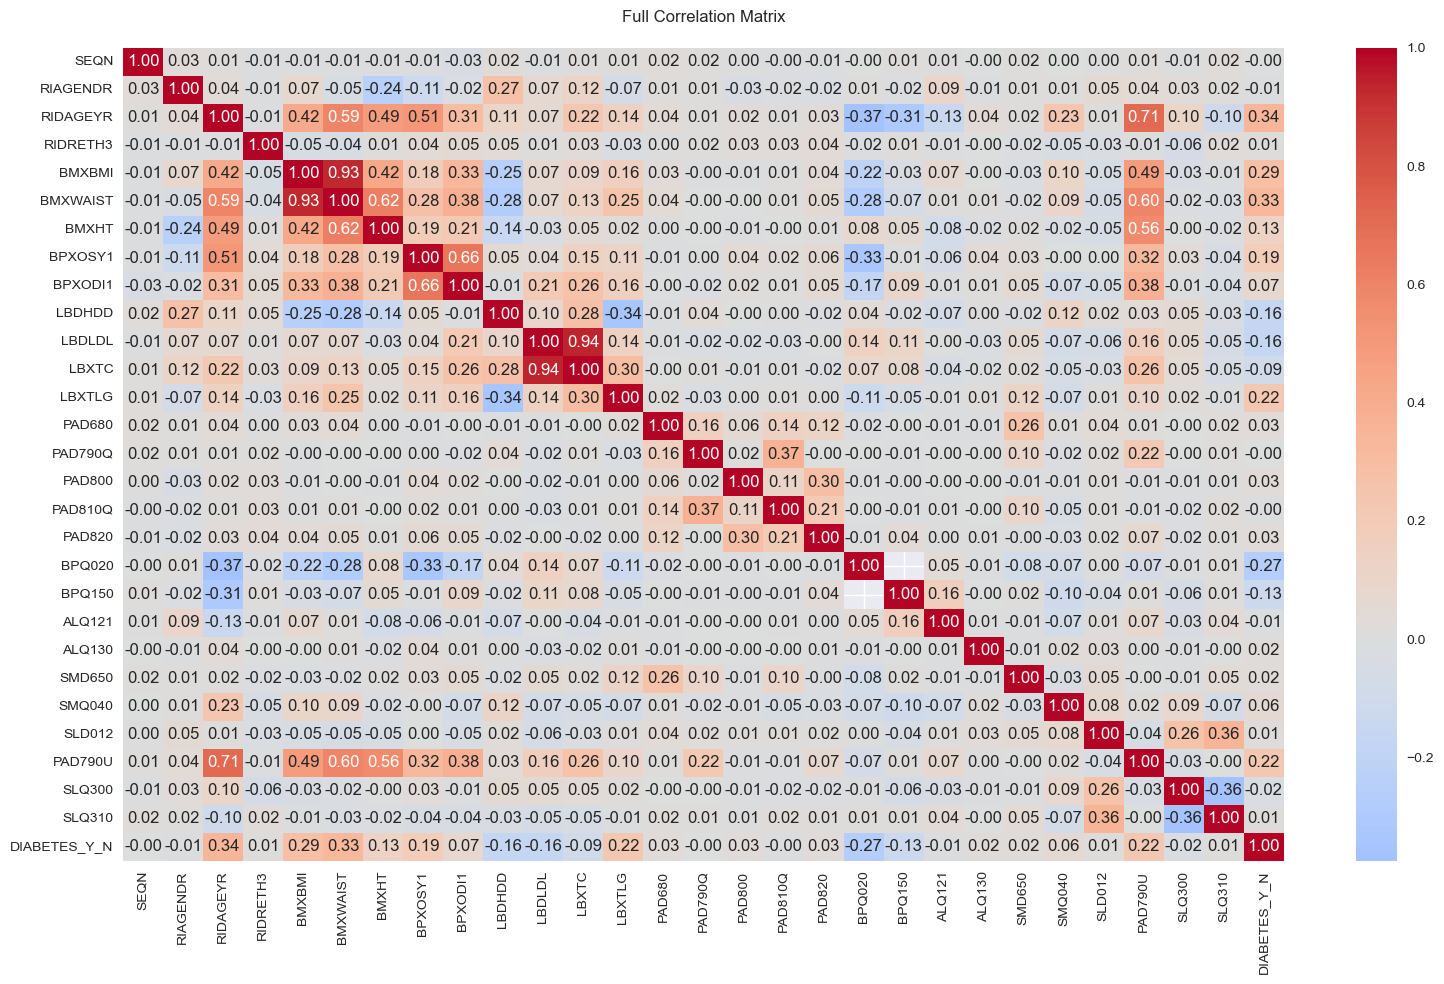

In [16]:
feature_cols = [col for col in df.columns if col != 'DIABETES_Y_N']
num_features = df[feature_cols].select_dtypes(include=['number']).columns.tolist()
corr_matrix = df[num_features + ['DIABETES_Y_N']].corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Full Correlation Matrix\n')
plt.tight_layout()
plt.show()

### Interpretation: Multivariate Analysis

The heatmap reflects which variables are strongly related to diabetes, and which are redundant (multicollinear).

1. #### Strong positive correlation with diabetes outcome (DIABETES_Y_N):

    The attributes, RIDAGEYR (Age) = 0.34, BMXWAIST (Waist Circumference) = 0.33, and BMXBMI (BMI) = 0.29 show a stronger correlation with diabetes outcome. Diabetes risk increases with age, waist circumference, and BMI.
  
2. ### Moderate positive correlation to diabetes outcome (DIABETES_Y_N):

    The attributes, LBXTLG (Triglyceride) = 0.22, PAD790U (Moderate Physical Activity) = 0.22, and BPXOSY1 (BP Systolic) = 0.19 show a moderate correlation with diabetes outcome. 

3. ### Negative Correlation:

   * **LBDHDD (HDL cholesterol):** Shows correlation of -0.16. Higher HDL (“good cholesterol”) is associated with lower diabetes risk.
   
   * **LBDLDL (LDL cholesterol0:** Shows correlation of -0.16. LDL (“bad cholesterol”) surprisingly shows a negative correlation. Often, diabetes is linked to low LDL
  
   * **BPQ020 (Doctor told you have hypertension):** Correlation of -0.27. A negative correlation suggests that people reporting hypertension are less likely to be diabetic in this dataset. This is counterintuitive and may reflect survey coding issues or confounding factors (e.g., younger hypertensive individuals without diabetes).


### Univariate Analysis

* Multivariate heatmap provides the correlation of all the attributes with diabetes label. We will perform univariate analysis for the attributes that show strong and moderate correlation to diabetes outcome. 
* We perform univariate analysis to understand the central tendency, spread, skewness, and potential outliers of an individual attribute.

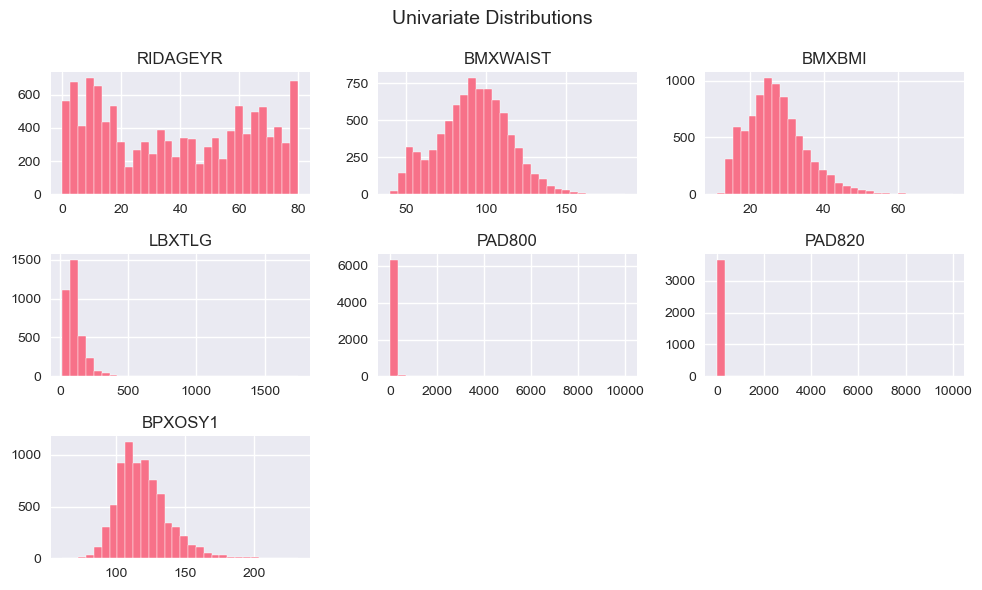

In [17]:
# ========================================================================================================
# 1. Univariate distribution for attributes that show strong or moderate correlation with diabetes outcome
# ========================================================================================================

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
key_numeric = ["RIDAGEYR", "BMXWAIST", "BMXBMI", "LBXTLG", "PAD800", "PAD820", "BPXOSY1"]
key_numeric = [c for c in key_numeric if c in df.columns]

df[key_numeric].hist(bins=30, figsize=(10, 6))
plt.suptitle("Univariate Distributions", fontsize=14)
plt.tight_layout()
plt.show()


### Interpretation: Univariate Analysis

It helps to understand the central tendency, spread, skewness, and potential outliers of an individual attribute. For example,
* **RIDAGEYR (Age):** Distribution is fairly broad, with peaks at younger ages and again at older ages. The dataset includes both children and adults, with noticeable representation across age groups.
* **BMXBMI (Body Mass Index):** Most values are clustering towards the overweight range (25-30) indicating overweight/obese prevalence, known to be a diabetes risk factor. Also, the long tail suggests severe obesity cases, which are fewer but clinically important.
* **BMXWAIST (Waist Circumference):** It is a very strong predictor of diabetes risk. It follows bell-shaped curve, but slightly right-skewed. The concentration is around 80-110 cm, showing that most participants cluster around the central obesity thresholds. The tail extends beyond 140-170 cm. Theses outliers are likely real and should not be ignored due to high risk.
* **LBXTLG (Triglycerides):** Shows a strong right skew. Most of the participants have normal triglyceride levels, but a few are outliers driving the long tail. This variable likely needs log transformation for modeling.
* **PAD800 and PAD820:** The distribution has a heavy concentration near 0, with some extreme coded values (likely 9999 for “missing” or “don’t know”). These need cleaning — recoding or removing values before analysis. The clustering near 0 suggests many participants report little or no activity.
* **BPXOSY1 (Systolic Blood Pressure):** Thed distribution peaks around 120-130. Most participants fall in the normal-to-prehypertensive range, with some hypertensive outliers.

### Class Distribution

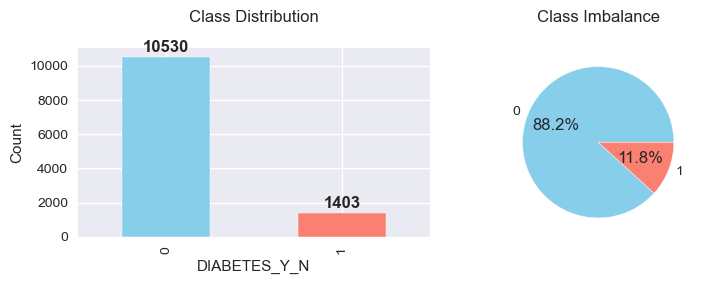

In [18]:
import matplotlib.pyplot as plt

colors = ['skyblue', 'salmon']
counts = df['DIABETES_Y_N'].value_counts()
counts_norm = df['DIABETES_Y_N'].value_counts(normalize=True)

plt.figure(figsize=(8, 3))
ax1 = plt.subplot(1, 2, 1)  # Row 1, Col 2, Position 1 (bar)
counts.plot(kind='bar', color=colors, ax=ax1)
ax1.set_title('Class Distribution\n')
ax1.set_ylabel('Count')

# Add labels on bars
max_count = max(counts.values)
for i, v in enumerate(counts.values):
    ax1.text(i, v + max_count * 0.01, str(int(v)), 
             ha='center', va='bottom', fontweight='bold')

ax2 = plt.subplot(1, 2, 2)  # Row 1, Col 2, Position 2 (pie)
counts_norm.plot(kind='pie', colors=colors, ax=ax2, autopct='%1.1f%%')
ax2.set_title('Class Imbalance\n')
ax2.set_ylabel('')  # Remove y-label for pie

plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
class_counts =  df['DIABETES_Y_N'].value_counts()
print("\nClass Frequencies:\n", class_counts)
print("\nTarget Distribution:\n", df['DIABETES_Y_N'].value_counts(normalize=True))

# Check imbalance ratio
balance_ratio = df['DIABETES_Y_N'].value_counts()[0] / df['DIABETES_Y_N'].value_counts()[1]
print(f"\nImbalance Ratio (No:Yes): {balance_ratio:.2f}")


Class Frequencies:
 DIABETES_Y_N
0    10530
1     1403
Name: count, dtype: int64

Target Distribution:
 DIABETES_Y_N
0    0.882427
1    0.117573
Name: proportion, dtype: float64

Imbalance Ratio (No:Yes): 7.51


### Interpretation: Class Distribution

Considering the significant class imbalance for target variable (DIABETES_Y_N), we need to apply a smoothing technique like SMOTE to address class imbalance via oversampling.

In [20]:
# ================================
# Bivariate: BMI vs HbA1c by class
# ================================
#if set(["BMXBMI", "LBXGH"]).issubset(df.columns):
#    plt.figure(figsize=(6,4))
#    sns.scatterplot(
#        data=df,
#        x="BMXBMI",
#        y="LBXGH",
#        hue="DIABETES_Y_N",
#        alpha=0.5
#    )
#    plt.title("BMXBMI vs LBXGH by Diabetes Status")
#    plt.show()

#corr_matrix = df.corrwith(pd.Series(y_res, name='DIABETES_Y_N')).to_frame('DIABETES_Y_N')

#plt.figure(figsize=(20, 5))
#sns.heatmap(corr_matrix.T, annot=True, cmap='coolwarm', center=0, fmt='.2f')
#plt.title('Feature Correlation with Diabetes Risk\n')
#plt.tight_layout()
#plt.show()

## 3) Data Cleansing / Preprocessing (Missing Values, Outliers)

### Display value counts for Valid values, Don't Know, and Missing values for select attributes

In [21]:
# ==================
# List of attributes
# ==================
attrs = ["PAD800", "PAD810Q", "PAD820", "BPQ020", "BPQ150", 
        "ALQ121", "ALQ130", "SMD650", "SLQ300", "SLQ310"]

# ==================================================
# NHANES DK codes: 9/77/99/777/999/77777/99999 → NaN
# ==================================================
dk_codes = [9, 77, 99, 777, 999, 77777, 99999]

is_dk = df[attrs].isin(dk_codes)
is_missing = df[attrs].isna()
is_valid = ~(is_dk | is_missing)

status_summary = pd.DataFrame({
    'Valid': is_valid.sum(),
    'Dont_Know': is_dk.sum(),
    'Missing': is_missing.sum()
}, index=attrs).round(0).astype(int)

print("Status Summary:\n", status_summary)


Status Summary:
          Valid  Dont_Know  Missing
PAD800    6390          0     5543
PAD810Q   8137          2     3794
PAD820    3687          0     8246
BPQ020    8488         10     3435
BPQ150    2965          4     8964
ALQ121    4400        522     7011
ALQ130    4036         33     7864
SMD650    1172         13    10748
SLQ300    8325         21     3587
SLQ310    7999        384     3550


### Convert Don't Know to Missing Values (NaN)

In [22]:
# =============================
# Convert DK → NaN (vectorized)
# =============================
df[attrs] = df[attrs].where(~is_dk, np.nan)

is_dk = df[attrs].isin(dk_codes)
is_missing = df[attrs].isna()
is_valid = ~(is_dk | is_missing)

status_summary = pd.DataFrame({
    'Valid': is_valid.sum(),
    'Dont_Know': is_dk.sum(),
    'Missing': is_missing.sum()
}, index=attrs).round(0).astype(int)

print("Status summary after converting Don't Know to Missing Values:\n\n", status_summary)


Status summary after converting Don't Know to Missing Values:

          Valid  Dont_Know  Missing
PAD800    6390          0     5543
PAD810Q   8137          0     3796
PAD820    3687          0     8246
BPQ020    8488          0     3445
BPQ150    2965          0     8968
ALQ121    4400          0     7533
ALQ130    4036          0     7897
SMD650    1172          0    10761
SLQ300    8325          0     3608
SLQ310    7999          0     3934


### Missing Value Analysis

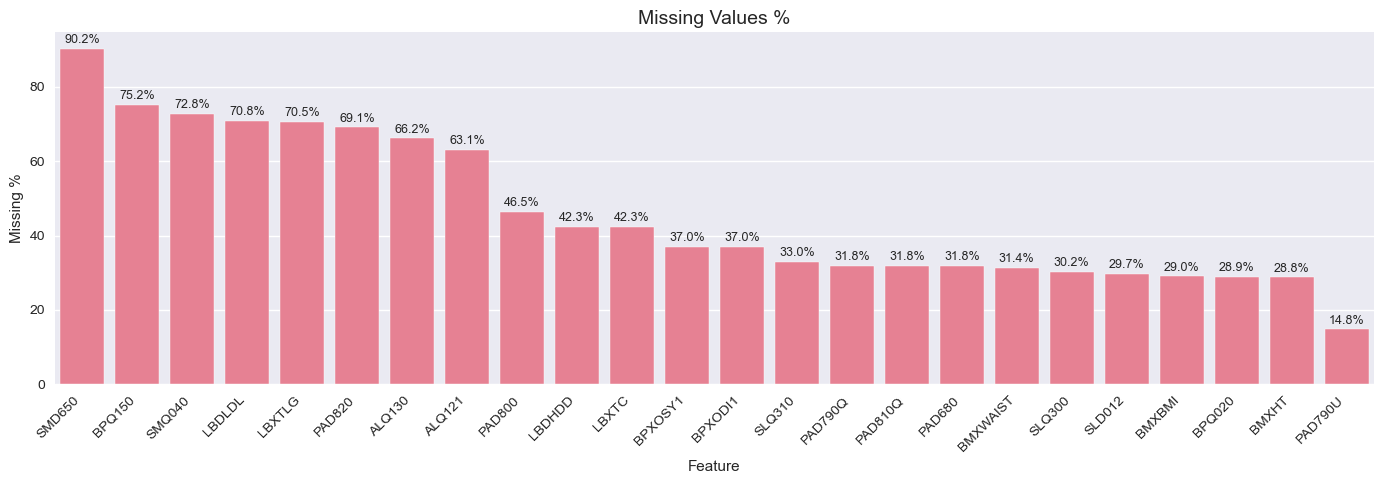

In [23]:
missing_pct = df.isnull().sum() / len(df) * 100
missing_df = pd.DataFrame({'Feature': missing_pct.index, 'Missing %': missing_pct.values})
missing_df = missing_df[missing_df['Missing %'] > 0].sort_values('Missing %', ascending=False)

plt.figure(figsize=(14, 5))  # Wider + taller
ax = sns.barplot(data=missing_df, x='Feature', y='Missing %')
plt.xticks(rotation=45, ha='right')  # Better alignment
plt.title('Missing Values %', fontsize=14)

# Method 1: bar_label with small font + padding
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontsize=9, padding=2)  # Smaller font, more padding

plt.tight_layout()
plt.savefig('missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation: Missing Value

When we have very high percentages of missing values (like 90% for SMD650, 75% for BPQ150, and 73% for SMQ040), the strategy depends on both the importance of the variable and the nature of the missingness.
* **Bias risk:** Imputing when >70–90% of data is missing often introduces bias rather than improving the model.
* **Information loss:** Such variables contribute little predictive power because they’re missing for most participants.
* **Noise:** Keeping them may add noise and reduce model stability.

For variables with more than 70–80% missingness, especially if they’re not central to the analysis, it’s often best to exclude them.


### Check for NaN Values

In [24]:
# ===================
# Check ALL NaNs/Infs
# ===================
print("NaN count per column:")
nan_cols = df.isna().sum()
print(nan_cols[nan_cols > 0].sort_values(ascending=False))

print("\nInf check:")
inf_cols = np.isinf(df.select_dtypes(include=[np.number])).sum()
print(inf_cols[inf_cols > 0])


NaN count per column:
SMD650      10761
BPQ150       8968
SMQ040       8690
LBDLDL       8453
LBXTLG       8416
PAD820       8246
ALQ130       7897
ALQ121       7533
PAD800       5543
LBDHDD       5043
LBXTC        5043
BPXOSY1      4416
BPXODI1      4416
SLQ310       3934
PAD790Q      3798
PAD810Q      3796
PAD680       3795
BMXWAIST     3743
SLQ300       3608
SLD012       3545
BMXBMI       3462
BPQ020       3445
BMXHT        3434
PAD790U      1763
dtype: int64

Inf check:
Series([], dtype: Int64)


### Exclude attributes with high percentage of missing values from predictors

In [25]:
# =========================================================================
# EXCLUDE attributes with high percentage of missing values from predictors
# SMD650: Average cigarettes per day
# BPQ150: Taking BP Medicines
# SMQ040: Do you smoke now?
# =========================================================================

exclude_cols = ['SMD650', 'BPQ150', 'SMQ040']
df_missing_value = df.copy()
df = df.drop(exclude_cols, axis=1).copy()

print("Dataset shape:", df.shape)

Dataset shape: (11933, 26)


### Replace all missing values with median values

In [26]:
# =========================================================================================
# Replace missing values with median values. We do not need to specify column names. 
# Every column's missing value is replaced with that column's median value respectively.
# Note: As a best practice, we will take a copy of the dataframe before inputing the values
# =========================================================================================
df2 = df.copy()
df = df.fillna(df.median())
df.isnull().sum()

SEQN            0
RIAGENDR        0
RIDAGEYR        0
RIDRETH3        0
BMXBMI          0
BMXWAIST        0
BMXHT           0
BPXOSY1         0
BPXODI1         0
LBDHDD          0
LBDLDL          0
LBXTC           0
LBXTLG          0
PAD680          0
PAD790Q         0
PAD800          0
PAD810Q         0
PAD820          0
BPQ020          0
ALQ121          0
ALQ130          0
SLD012          0
PAD790U         0
SLQ300          0
SLQ310          0
DIABETES_Y_N    0
dtype: int64

In [27]:
# ===================
# Check ALL NaNs/Infs
# ===================
print("NaN count per column:")
nan_cols = df.isna().sum()
print(nan_cols[nan_cols > 0].sort_values(ascending=False))

print("\nInf check:")
inf_cols = np.isinf(df.select_dtypes(include=[np.number])).sum()
print(inf_cols[inf_cols > 0])

NaN count per column:
Series([], dtype: int64)

Inf check:
Series([], dtype: Int64)


RIAGENDR       Axes(0.125,0.814746;0.110714x0.0652542)
RIDAGEYR    Axes(0.257857,0.814746;0.110714x0.0652542)
RIDRETH3    Axes(0.390714,0.814746;0.110714x0.0652542)
BMXBMI      Axes(0.523571,0.814746;0.110714x0.0652542)
BMXWAIST    Axes(0.656429,0.814746;0.110714x0.0652542)
BMXHT       Axes(0.789286,0.814746;0.110714x0.0652542)
BPXOSY1        Axes(0.125,0.736441;0.110714x0.0652542)
BPXODI1     Axes(0.257857,0.736441;0.110714x0.0652542)
LBDHDD      Axes(0.390714,0.736441;0.110714x0.0652542)
LBDLDL      Axes(0.523571,0.736441;0.110714x0.0652542)
LBXTC       Axes(0.656429,0.736441;0.110714x0.0652542)
LBXTLG      Axes(0.789286,0.736441;0.110714x0.0652542)
PAD680         Axes(0.125,0.658136;0.110714x0.0652542)
PAD790Q     Axes(0.257857,0.658136;0.110714x0.0652542)
PAD800      Axes(0.390714,0.658136;0.110714x0.0652542)
PAD810Q     Axes(0.523571,0.658136;0.110714x0.0652542)
PAD820      Axes(0.656429,0.658136;0.110714x0.0652542)
BPQ020      Axes(0.789286,0.658136;0.110714x0.0652542)
ALQ121    

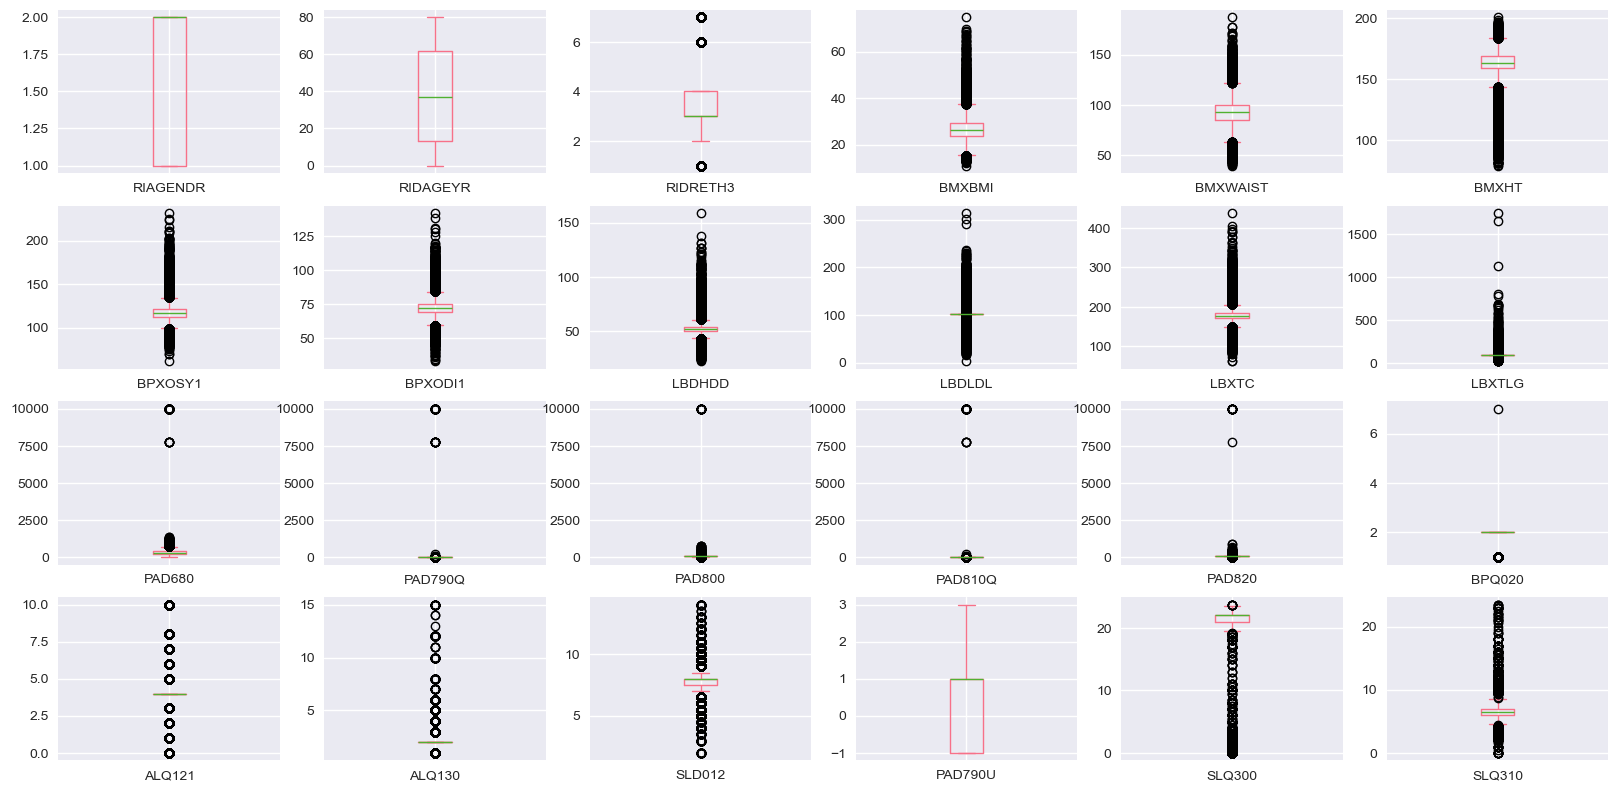

In [28]:
# =============================================================================================
# Box Plot for all Independent Variables. Exclude SEQN (ID) and DIABETES_Y_N (target) variables
# =============================================================================================
exclude_cols = ['SEQN', 'DIABETES_Y_N']
plot_df = df.loc[:, ~df.columns.isin(exclude_cols)]

plot_df.plot(kind='box', subplots=True, layout=(10,6), sharex=False, sharey=False, figsize=(20,25))

### Addressing Outliers
* RIAGENDR (Gender): Boxplot reveals a balanced gender distribution.
* RIDAGEYR (Age): Ranges from infancy to ~80 years, with a median in the mid-30s. Outliers at very young or very old ages are valid and retained.
* BMXBMI (Body Mass Index): Values cluster around overweight range (25–30). High outliers are clinically important (extreme obesity) and retained.
* BMXWAIST (Waist Circumference): Concentrate around 80-110 cm (obesity threshold). High outliers (severe obesity) represent high-risk individuals and retained.
* LBXTC (Total Cholesterol): Boxplot shows several high outliers (>300–400 mg/dL). They are high-risk individuals and retained.
* LBXTLG (Triglycerides): Most have normal levels (75% <136). High outliers are clinically significant and retained. Extreme values are capped.

In [29]:
# ===================================================================
# Define capping threshold (e.g., 99th percentile or clinical cutoff)
# ===================================================================
cap_value = df['LBXTLG'].quantile(0.99)   # or use a fixed cutoff like 1000

# ===================================
# Overwrite LBXTLG with capped values
# ===================================
df['LBXTLG_capped_flag'] = np.where(df['LBXTLG'] > cap_value, 1, 0)
df['LBXTLG'] = np.where(df['LBXTLG'] > cap_value, cap_value, df['LBXTLG'])

# =================================
# Count how many values were capped
# =================================
num_capped = df['LBXTLG_capped_flag'].sum()
print(f"Number of capped values: {num_capped}")

Number of capped values: 120


In [30]:
# Boxplot example: BMI vs diabetes
#sns.boxplot(x="DIABETES_Y_N", y="BMXBMI", data=df)
#plt.title("BMI Distribution by Diabetes Status")
#plt.show()

# Countplot example: Gender vs diabetes
# sns.countplot(x="RIAGENDR", hue="DIABETES_Y_N", data=df)
# plt.title("Gender vs Diabetes Status")
# plt.show()

## 4) Feature Engineering (Derived Features, Composite Scores)

### Create a compsoste score: simple metabolic risk index

In [31]:
print("Feature set shape before engineering:", df.shape)

# Create BP averages
#sys_cols = ["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"]
#dia_cols = ["BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4"]

#df2["avg_systolic"]  = df2[sys_cols].mean(axis=1, skipna=True)
#df2["avg_diastolic"] = df2[dia_cols].mean(axis=1, skipna=True)

# ============================================
# Composite score: simple metabolic risk index
# ============================================

for col in ["BMXBMI", "BMXWAIST", "BPXOSY1", "LBXTC"]:
    if col not in df.columns:
        print(f"Warning: {col} not in dataset; skipping composite score.")
        break
else:
    df["metabolic_risk_score"] = (
        (df["BMXBMI"] - df["BMXBMI"].mean()) / df["BMXBMI"].std() +
        (df["BMXWAIST"] - df["BMXWAIST"].mean()) / df["BMXWAIST"].std() +
        (df["BPXOSY1"] - df["BPXOSY1"].mean()) / df["BPXOSY1"].std() +
        (df["LBXTC"] - df["LBXTC"].mean()) / df["LBXTC"].std()
    )

# ================================================================================================
# BRI (Body Roundness Index) formula: models body as ellipse using waist/height (NHANES units: cm)
# Convert to meters for standard formula
# ================================================================================================
waist_m = df['BMXWAIST'] / 100  # cm → m
height_m = df['BMXHT'] / 100    # cm → m

# ================================
# Body Roundness Index (BRI)
# bri < 3.4 = Low Risk
# bri > 3.4 < 5.8 = Moderate Risk
# bri > 5.8 < 7.0 = High Risk
# bri > 7.0 = Very High Risk
# ================================

df['BRI'] = 364.2 - 365.5 * np.sqrt(1 - ((waist_m / (np.pi * height_m))**2))

print("\nBRI created. Range:", df['BRI'].min(), "to", df['BRI'].max())
print("\nBRI describe:\n", df['BRI'].describe())


Feature set shape before engineering: (11933, 27)

BRI created. Range: 0.14771941704111669 to 23.814838818243004

BRI describe:
 count    11933.000000
mean         4.989620
std          2.144039
min          0.147719
25%          3.812265
50%          4.694133
75%          5.576178
max         23.814839
Name: BRI, dtype: float64


### Harmonize moderate activity in minutes per week

In [32]:
def sessions_per_week(freq, unit_num):
    if freq <= 0:
        return 0
    unit_factors = {1: 7.0, 2: 1.0, 3: 1/4.33, 4: 1/52.0}  # NHANES standard
    return freq * unit_factors.get(unit_num, 1.0)

df['modact_sessions_per_week'] = df.apply(
#    lambda row: sessions_per_week(row['PAD790Q'], row['PAD790U_num']), axis=1
    lambda row: sessions_per_week(row['PAD790Q'], row['PAD790U']), axis=1
)
df['modact_minutes_per_week'] = df['modact_sessions_per_week'] * df['PAD800']

# ================================================================
# Final clip (2000 min/week max = ~5hrs/day realistic upper limit)
# ================================================================
df['modact_minutes_per_week'] = df['modact_minutes_per_week'].clip(0, 2000)

# ======
# Verify
# ======
print("\n✅ Moderate physical activity (min/week) created:")
print(df['modact_minutes_per_week'].describe())
print("\nDistribution:")
print(pd.cut(df['modact_minutes_per_week'], 
             bins=[0, 150, 300, 600, 2000], 
             labels=['Inactive', 'Active', 'Very Active', 'Extreme']).value_counts())

print("\nMissing % AFTER PA harmonization:")
print(df.isnull().sum()[df.isnull().sum() > 0] / len(df) * 100)

df.drop('modact_sessions_per_week', axis=1, inplace=True)
print("\nFeature set shape after engineering:", df.shape)

df_fe = df.copy()



✅ Moderate physical activity (min/week) created:
count    1.193300e+04
mean     5.347424e+02
std      6.767794e+02
min      2.266994e-76
25%      1.200000e+02
50%      1.200000e+02
75%      8.400000e+02
max      2.000000e+03
Name: modact_minutes_per_week, dtype: float64

Distribution:
modact_minutes_per_week
Inactive       6807
Extreme        3825
Very Active     781
Active          520
Name: count, dtype: int64

Missing % AFTER PA harmonization:
Series([], dtype: float64)

Feature set shape after engineering: (11933, 30)


## 5) Data Split

* Split the dataset before normalizing and addressing data imbalance to avoid data leak. SMOTE will be applied only for training data.
* The test set should simulate unseen, real-world data. If preprocessing is done before splitting, the test set is no longer independent, and evaluation metrics will be overly optimistic.

In [33]:
# ==============================
# Separate target and predictors
# ==============================
y = df["DIABETES_Y_N"].astype(int)
X = df.drop(columns=["DIABETES_Y_N"])

# ==========================
# Train / Test Split (80/20)
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (9546, 29) Test shape: (2387, 29)


## 6) Normalize + Encode Features on Training Data

#### Normalization

* This steps ensures that diabetes risk model learns equally from all features (BMI, age, etc.) regardless of their original scales.
* Without normalization, features like BMI may dominate simply because they have larger numeric ranges.
* Normalization ensures each feature contributes proportionally.
* SMOTE and most models require numeric, and scaled inputs.

#### Encode Categorical Features

* 1) One-hot encoding for nominal categories (e.g., ethnicity), 2) Label encoding or embeddings for ordinal categories.

#### Note
* For this dataset, all are numeric after our conversions, so encoding is already implicit. We will focus on scaling (StandardScaler).

In [34]:
#num_cols_train = X_train.columns  # all numeric at this point
feature_cols = [col for col in X_train.columns if col != 'SEQN']  # 27 clinical vars

X_train_no_seqn = X_train[feature_cols]
X_test_no_seqn = X_test[feature_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_no_seqn)
X_test_scaled = scaler.transform(X_test_no_seqn)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("Scaling complete. Mean/std (train):\n")
print(X_train_scaled.describe().loc[["mean", "std"]].round(2))

Scaling complete. Mean/std (train):

      RIAGENDR  RIDAGEYR  RIDRETH3  BMXBMI  BMXWAIST  BMXHT  BPXOSY1  BPXODI1  \
mean      -0.0      -0.0      -0.0     0.0      -0.0    0.0      0.0      0.0   
std        1.0       1.0       1.0     1.0       1.0    1.0      1.0      1.0   

      LBDHDD  LBDLDL  ...  ALQ121  ALQ130  SLD012  PAD790U  SLQ300  SLQ310  \
mean     0.0    -0.0  ...    -0.0    -0.0    -0.0     -0.0    -0.0     0.0   
std      1.0     1.0  ...     1.0     1.0     1.0      1.0     1.0     1.0   

      LBXTLG_capped_flag  metabolic_risk_score  BRI  modact_minutes_per_week  
mean                 0.0                  -0.0 -0.0                     -0.0  
std                  1.0                   1.0  1.0                      1.0  

[2 rows x 28 columns]


## 7) Dimensionality Reduction/Feature Selection using Elastic Net (L1 + L2 Regularization)

* L1 provides feature selection, while L2 handles multicollinearity.
* It shrinks coefficients and drops irrelevant predictors.
* Cross-validation ensures robust selection.
* Coefficient table provides interpretable weights — features with coefficients shrunk to ~0 are less important, while strong positive/negative coefficients highlight key risk drivers.


In [35]:
from sklearn.linear_model import ElasticNetCV, LogisticRegressionCV  # CV for binary; use Logistic for classification
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import roc_auc_score

# ========================================================================
# ElasticNetCV auto-tunes alpha/l1_ratio via CV (stratified for imbalance)
# ========================================================================
enet = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],  # Mix L1/L2
    alphas=np.logspace(-4, 1, 20),  # Wide range
    cv=5, random_state=RANDOM_STATE, max_iter=1000
)

# =====================================
# Fit on train (for binary DIABETES_Y_N
# =====================================
enet.fit(X_train_scaled, y_train)

# =================
# Print best params
# =================
print(f"Best alpha: {enet.alpha_:.4f}, l1_ratio: {enet.l1_ratio_}")

# =======================================================
# Select features (threshold mean abs coeff for sparsity)
# =======================================================
selector = SelectFromModel(enet, threshold='mean') 
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X_train_scaled.columns[selector.get_support()]
print(f"Selected {len(selected_features)} features: {selected_features.tolist()}")

# =========================================
# Quick eval (replace with the risk scorer)
# =========================================
print(f"Train AUC: {roc_auc_score(y_train, enet.predict(X_train_scaled)):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, enet.predict(X_test_scaled)):.3f}")


Best alpha: 0.0021, l1_ratio: 0.7
Selected 10 features: ['RIDAGEYR', 'BMXBMI', 'BPXOSY1', 'BPXODI1', 'LBDHDD', 'LBXTC', 'LBXTLG', 'BPQ020', 'BRI', 'modact_minutes_per_week']
Train AUC: 0.877
Test AUC: 0.871


In [36]:
# ===================================
# Coefficients and Feature Importance
# ===================================
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': enet.coef_,
    'Abs_Coefficient': np.abs(enet.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print(coef_df.round(4).to_markdown(index=False))  # Or .to_latex() for report

# ============
# Top features
# ============
print("\nTop 10 features:")
print(coef_df.head(10))


| Feature                 |   Coefficient |   Abs_Coefficient |
|:------------------------|--------------:|------------------:|
| RIDAGEYR                |        0.0716 |            0.0716 |
| BPQ020                  |       -0.0552 |            0.0552 |
| LBXTLG                  |        0.0367 |            0.0367 |
| BRI                     |        0.0301 |            0.0301 |
| BPXODI1                 |       -0.0295 |            0.0295 |
| LBXTC                   |       -0.0275 |            0.0275 |
| BPXOSY1                 |        0.0242 |            0.0242 |
| BMXBMI                  |        0.0205 |            0.0205 |
| modact_minutes_per_week |       -0.018  |            0.018  |
| LBDHDD                  |       -0.0176 |            0.0176 |
| LBDLDL                  |       -0.0127 |            0.0127 |
| BMXHT                   |       -0.0108 |            0.0108 |
| PAD800                  |        0.0064 |            0.0064 |
| RIAGENDR                |       -0.006

### Interpretation of L1+L2 Regularization
The Elastic Net output (alpha=0.0021, l1_ratio=0.7) identifies a sparse, stable 10-feature model for diabetes risk score, with excellent discriminative power (AUC 0.877 train/0.871 test), indicating low overfitting and strong generalizability.

#### Feature Importance Summary
Coefficients indicate direction and strength of association with diabetes risk:
* **Positive coefficients (increase risk score):**
    * RIDAGEYR (Age, +0.072) → Older age strongly increases risk.
    * LBXTLG (Triglycerides, +0.037) → Higher triglycerides elevate risk.
    * BRI (Body Roundness Index, +0.030) → Central obesity contributes to risk.
    * BPXOSY1 (Systolic BP, +0.024) → Higher systolic pressure increases risk.
    * BMXBMI (BMI, +0.021) → Higher BMI adds risk.<br><br>

* **Negative coefficients (protective / inverse association):**
    * BPQ020 (Blood pressure, -0.055) → Indicates those reporting awareness/treatment have lower risk
    * BPXODI1 (Diastolic BP, -0.029) → Lower diastolic pressure linked to higher risk, but effect is weaker.
    * LBXTC (Total cholesterol, -0.027) → Slight inverse effect; may reflect complex lipid interactions.
    * modact_minutes_per_week (Moderate activity, -0.018) → More physical activity reduces risk.
    * LBDHDD (HDL cholesterol, -0.018) → Higher HDL is protective

## 8) Address class imbalance using SMOTE for training data

In [37]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_selected, y_train) # y_train (original)

print(f"Pre-SMOTE train shape: {X_train_selected.shape}, Class distribution: {np.bincount(y_train)}")
print(f"Post-SMOTE train shape: {X_train_bal.shape}, Class distribution: {np.bincount(y_train_bal)}")

print("\nClass balance before SMOTE:\n")
print(y_train.value_counts(normalize=True))

print("\nClass balance after SMOTE:\n")
print(pd.Series(y_train_bal).value_counts(normalize=True))

Pre-SMOTE train shape: (9546, 10), Class distribution: [8424 1122]
Post-SMOTE train shape: (16848, 10), Class distribution: [8424 8424]

Class balance before SMOTE:

DIABETES_Y_N
0    0.882464
1    0.117536
Name: proportion, dtype: float64

Class balance after SMOTE:

DIABETES_Y_N
0    0.5
1    0.5
Name: proportion, dtype: float64


In [38]:
print("=== SHAPE VERIFICATION ===")
print("Original train:", X_train.shape, y_train.shape)
print("L1+L2 train:", X_train_selected.shape, y_train.shape)
print("SMOTE train (balanced):", X_train_bal.shape, y_train_bal.shape)
print("Test (unchanged):", X_test_selected.shape, y_test.shape)
print("Current X_test_L1L2.shape:", X_test_selected.shape)  # Should be (2387, 20)

=== SHAPE VERIFICATION ===
Original train: (9546, 29) (9546,)
L1+L2 train: (9546, 10) (9546,)
SMOTE train (balanced): (16848, 10) (16848,)
Test (unchanged): (2387, 10) (2387,)
Current X_test_L1L2.shape: (2387, 10)


## 9) Build a baseline AutoML model (LR, KNN, NN) for benchmarking

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# =============================
# 1. Logistic Regression AutoML
# =============================
lr_params = {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2']}
lr_auto = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), 
                      lr_params, cv=5, scoring='roc_auc')
lr_auto.fit(X_train_bal, y_train_bal)
#print("Best LR:", lr_auto.best_score_, "Test AUC:", roc_auc_score(y_test, lr_auto.predict_proba(X_test_selected)[:,1]))

# =============
# 2. KNN AutoML
# =============
knn_params = {'n_neighbors': [3,5,7,9], 'weights': ['uniform', 'distance']}
knn_auto = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='roc_auc')
knn_auto.fit(X_train_bal, y_train_bal)
#print("Best KNN:", knn_auto.best_score_, "Test AUC:", roc_auc_score(y_test, knn_auto.predict_proba(X_test_selected)[:,1]))

# ========================
# 3. Neural Network AutoML
# ========================
nn_params = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)],
    'alpha': [0.0001, 0.001],  # L2 regularization
    'learning_rate_init': [0.001, 0.01]
}
nn_auto = GridSearchCV(MLPClassifier(max_iter=500, random_state=42), 
                      nn_params, cv=5, scoring='roc_auc', n_jobs=-1)
nn_auto.fit(X_train_bal, y_train_bal)
#print("Best NN:", nn_auto.best_score_, "Test AUC:", roc_auc_score(y_test, nn_auto.predict_proba(X_test_selected)[:,1]))


GridSearchCV(cv=5, estimator=MLPClassifier(max_iter=500, random_state=42),
             n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001],
                         'hidden_layer_sizes': [(50,), (100,), (50, 50)],
                         'learning_rate_init': [0.001, 0.01]},
             scoring='roc_auc')

### Evaluate AutoML Model 


Logistic Regression Performance:
----------------------------------------
Accuracy:  0.7692
Precision: 0.3140
Recall:    0.8114
F1-Score:  0.4528
ROC-AUC:   0.8683


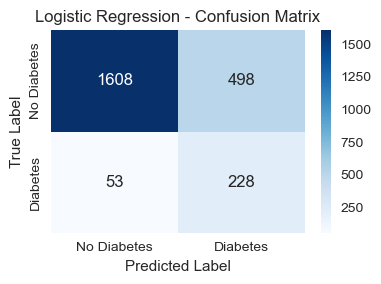


KNN Performance:
----------------------------------------
Accuracy:  0.7822
Precision: 0.3112
Recall:    0.7011
F1-Score:  0.4311
ROC-AUC:   0.8119


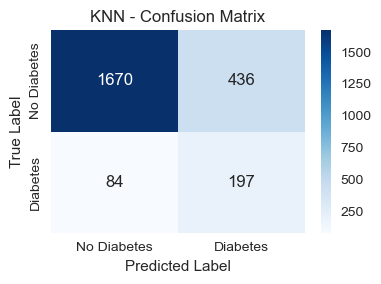


Neural Network Performance:
----------------------------------------
Accuracy:  0.8069
Precision: 0.3148
Recall:    0.5445
F1-Score:  0.3990
ROC-AUC:   0.8017


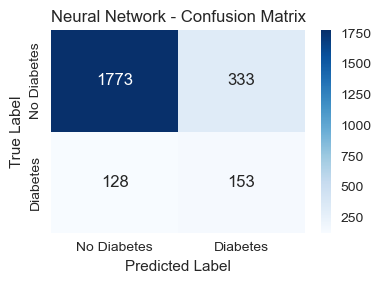


=== MODEL COMPARISON TABLE ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7692     0.3140  0.8114    0.4528   0.8683
KNN                    0.7822     0.3112  0.7011    0.4311   0.8119
Neural Network         0.8069     0.3148  0.5445    0.3990   0.8017

🏆 Best AutoML model: Logistic Regression (AUC: 0.8683)


In [40]:
def evaluate_model(model, X_test, y_test, model_name):
    """Comprehensive model evaluation"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
    print(f"\n{model_name} Performance:")
    print("-" * 40)
    print(f"Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall:    {metrics['Recall']:.4f}")
    print(f"F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"ROC-AUC:   {metrics['ROC-AUC']:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return metrics

# ==========================
# Evaluate all AutoML models
# ==========================
models = {
    'Logistic Regression': lr_auto,
    'KNN': knn_auto,
    'Neural Network': nn_auto
}

results = {}
for name, model in models.items():
    results[name] = evaluate_model(model, X_test_selected, y_test, name)

# ========================
# Summary comparison table
# ========================
results_df = pd.DataFrame(results).T
print("\n=== MODEL COMPARISON TABLE ===")
print(results_df.round(4))

# ==========================================================================
# Logistic Regression is the strongest performer - We will use as a baseline
# ==========================================================================
best_automl = lr_auto

print(f"\n🏆 Best AutoML model: Logistic Regression (AUC: {results['Logistic Regression']['ROC-AUC']:.4f})")


### Interpretation: Evaluation of autoML model

#### Logistic Regression (LR)
* Outperforms others overall with the highest ROC-AUC (0.8683) and best F1-score (0.4528), making it the strongest AutoML model for diabetes risk prediction despite modest precision.
* Strong Recall and ROC-AUC: It distinguishes well between classes and excells at identifying positive cases. Recall (81%) identifies 81% of true diabetics (critical for screening)
* Precision (32%): Indicates that 1/3 positive predictions are true. Low precision suggests that it may generate many false positive alarms.
* F1 (0.45): Best harmonic balance for imbalanced data

#### K-Nearest Neighbour (KNN)
* Middle ground, but doesn’t excel in any metric. It’s weaker than Logistic Regression in ROC-AUC and recall, and weaker than Neural Network in accuracy.

#### Neural Network (NN)
* Highest accuracy, but recall is very low. This means it predicts negatives correctly but fails to identify positives.
* Its ROC-AUC is also the weakest, suggesting poor overall classification balance.


## 10) Build Ensemble Models (RF, XGBoost)

Since the goal is to generate a risk score, not binary classification — so we will be considering probability outputs as the risk score (e.g., predicted probability of diabetes).

#### 1. Build RF Model
#### 2. Build XGB Model

In [41]:
# =======================
# Model 1. Build RF Model
# =======================
from imblearn.ensemble import BalancedRandomForestClassifier

print("\n--- Training Random Forest (RF) Model ---\n")

rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_auto = GridSearchCV(
    BalancedRandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, cv=5, scoring='roc_auc', n_jobs=-1
)

rf_auto.fit(X_train_bal, y_train_bal)
print(f"Best RF: {rf_auto.best_score_:.4f} Test AUC: {roc_auc_score(y_test, rf_auto.predict_proba(X_test_selected)[:,1]):.4f}")

# ========================
# Model 2. Build XGB Model
# ========================
print("\n--- Training XGB Model ---\n")

xgb_params = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 0.9],
    'scale_pos_weight': [len(y_train_bal[y_train_bal==0]) / len(y_train_bal[y_train_bal==1])]
}
xgb_auto = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='auc', n_jobs=-1),
    xgb_params, n_iter=20, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1
)

xgb_auto.fit(X_train_bal, y_train_bal)
print(f"Best XGB: {xgb_auto.best_score_:.4f} Test AUC: {roc_auc_score(y_test, xgb_auto.predict_proba(X_test_selected)[:,1]):.4f}")



--- Training Random Forest (RF) Model ---

Best RF: 0.9689 Test AUC: 0.8422

--- Training XGB Model ---

Best XGB: 0.9783 Test AUC: 0.8509


### Create soft voting ensemble (averages predicted probabilities)

In [42]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[('rf', rf_auto.best_estimator_), ('xgb', xgb_auto.best_estimator_)],
    voting='soft', n_jobs=-1
)

ensemble.fit(X_train_bal, y_train_bal)

VotingClassifier(estimators=[('rf',
                              BalancedRandomForestClassifier(n_estimators=300,
                                                             n_jobs=-1,
                                                             random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='auc',
                                            feature_types=None, gamma=...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=8,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=-1,
                                            num_parallel_tree=None,
                                            random_state=42, ...))],
                 n_jobs=-1, voting='soft')

### Evaluate Ensemble Model (RF + XGB)


Random Forest Performance:
----------------------------------------
Accuracy:  0.8328
Precision: 0.3659
Recall:    0.5730
F1-Score:  0.4466
ROC-AUC:   0.8422


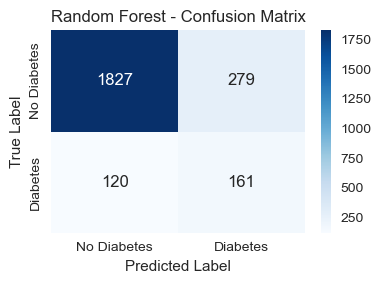


XGBoost Performance:
----------------------------------------
Accuracy:  0.8592
Precision: 0.4138
Recall:    0.4698
F1-Score:  0.4400
ROC-AUC:   0.8509


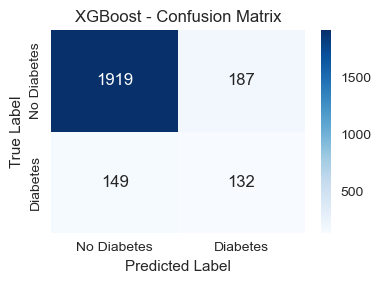

In [43]:
ensemble_results = {}
for name, model in [('Random Forest', rf_auto), ('XGBoost', xgb_auto)]:
    ensemble_results[name] = evaluate_model(model, X_test_selected, y_test, name)


## 11) Select the best overall model for XAI
#### a) Calculate and compare AUC, Precision, Recall, F1, and Scenario-based Score (balanced, screening, diagnosis)
#### b) Evaluate all the models considering scenario-based score
#### c) Select best performing model

### a) Calculate and compare AUC, Precision, Recall, F1, and Scenario-based Score (balanced, screening, diagnosis)
* **Balanced Scenario:** Clinical Use Case: General screening - balanced false positives/negatives
    * Priority: AUC + F1
    * Weight Focus: AUC(50%) + F1(25%) + Prec(15%) + Rec(10%)
    * Best Model: RF, XGB, Ensemble
* **Screening:** Clinical Use Case: Population screening - catch ALL diabetics (miss none)
    * Priority: Recall
    * Weight Focus: Recall(20%) + AUC(40%) + F1(30%) + Prec(10%)
    * Best Model: Random Forest
* **Diagnosis:** Clinical Use Case: Confirmatory testing - minimize false alarms (expensive tests)
    * Priority: Precision
    * Weight Focus: Precision(25%) + AUC(50%) + F1(25%)
    * Best Model: Logistic Regression

### b) Evaluate all the models considering business scenario-based score

In [44]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, precision_recall_curve

all_models = {
    'Logistic_Regression': lr_auto.best_estimator_,
    'KNN': knn_auto.best_estimator_,
    'Neural_Network': nn_auto.best_estimator_,
    'Random_Forest': rf_auto.best_estimator_,
    'XGBoost': xgb_auto.best_estimator_,
    'RF_XGB_Ensemble': ensemble
}

# =========================================
# Auto-select via weighted business metrics
# =========================================
def enhanced_business_score(model, X_test, y_test, name, scenario='Scenario'):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Core metrics
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    
    # Optimal F1 (best threshold for diabetes)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * prec * rec / (prec + rec + 1e-10)
    opt_f1 = np.max(f1_scores)
    
    # Scenario-based weights
    if scenario == 'screening':  # Maximize recall
        weights = {'auc': 0.4, 'opt_f1': 0.3, 'precision': 0.1, 'recall': 0.2}
    elif scenario == 'diagnosis':  # Maximize precision
        weights = {'auc': 0.5, 'opt_f1': 0.25, 'precision': 0.25, 'recall': 0.0}
    else:  # balanced
        weights = {'auc': 0.5, 'opt_f1': 0.25, 'precision': 0.15, 'recall': 0.1}
    
    # Composite Business Score
    business_score = (
        weights['auc'] * auc +
        weights['opt_f1'] * opt_f1 +
        weights['precision'] * precision +
        weights['recall'] * recall
    )
    
    return {
        'Model': name,
        'AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'Opt_F1': opt_f1,
        'Scenario_Score': business_score,
        'Scenario': scenario,
        'Weights': weights
    }

# =======================================================================
# Evaluate All Models for 3 Scenarios: Balanced, Screening, and Diagnosis
# =======================================================================
results = []
scenarios = ['balanced', 'screening', 'diagnosis']

for scenario in scenarios:
    print(f"\n🔍 Evaluating for '{scenario}' scenario...")
    scenario_results = []
    
    for name, model in all_models.items():
        result = enhanced_business_score(model, X_test_selected, y_test, name, scenario)
        scenario_results.append(result)
    
    scenario_df = pd.DataFrame(scenario_results).sort_values('Scenario_Score', ascending=False)
    print(scenario_df[['Model', 'AUC', 'Precision', 'Recall', 'Opt_F1', 'Scenario_Score']].round(4))
    
    # Track top model per scenario
    top_model = scenario_df.iloc[0]['Model']
    results.append({
        'Scenario': scenario,
        'Top_Model': top_model,
        'Top_Score': scenario_df.iloc[0]['Scenario_Score']
    })
    
    # Auto-select for this scenario
    globals()[f'best_model_{scenario}'] = all_models[top_model]

print("\n=== SCENARIO SUMMARY ===")
summary_df = pd.DataFrame(results)
print(summary_df.round(4))



🔍 Evaluating for 'balanced' scenario...
                 Model     AUC  Precision  Recall  Opt_F1  Scenario_Score
0  Logistic_Regression  0.8683     0.3140  0.8114  0.4765          0.6815
5      RF_XGB_Ensemble  0.8583     0.3861  0.4947  0.4730          0.6548
4              XGBoost  0.8509     0.4138  0.4698  0.4679          0.6514
3        Random_Forest  0.8422     0.3659  0.5730  0.4667          0.6500
1                  KNN  0.8119     0.3112  0.7011  0.4315          0.6306
2       Neural_Network  0.8017     0.3148  0.5445  0.4041          0.6035

🔍 Evaluating for 'screening' scenario...
                 Model     AUC  Precision  Recall  Opt_F1  Scenario_Score
0  Logistic_Regression  0.8683     0.3140  0.8114  0.4765          0.6839
3        Random_Forest  0.8422     0.3659  0.5730  0.4667          0.6281
1                  KNN  0.8119     0.3112  0.7011  0.4315          0.6256
5      RF_XGB_Ensemble  0.8583     0.3861  0.4947  0.4730          0.6228
4              XGBoost  0.850

#### c) Select the best performing model

In [45]:
balanced_results = [r for r in results if r['Scenario'] == 'balanced']
if balanced_results:
    balanced_row = balanced_results[0]  # Direct dict access
    best_name = balanced_row['Top_Model']
    best_score = balanced_row['Top_Score']
    
    # Get the actual model (safe)
    best_model_var = f"best_model_{balanced_row['Scenario']}"
    best_model = globals().get(best_model_var)
    
    print("\n" + "="*70)
    print("🏆 Best Performing Model:")
    print("="*70)
    
    # Scenario summary table
    scenario_df = pd.DataFrame(results)
    print(scenario_df[['Scenario', 'Top_Model', 'Top_Score']].round(4))
    
    print(f"\nBest Model: {best_name}")
    print(f"Balanced Score: {best_score:.4f}")
    
    # Set globals safely
    globals()['best_model'] = best_model
    globals()['best_model_name'] = best_name
    
else:
    print("\n❌ No 'balanced' results found!")

print("\n✅ Ready for XAI!")


🏆 Best Performing Model:
    Scenario            Top_Model  Top_Score
0   balanced  Logistic_Regression     0.6815
1  screening  Logistic_Regression     0.6839
2  diagnosis              XGBoost     0.6459

Best Model: Logistic_Regression
Balanced Score: 0.6815

✅ Ready for XAI!


## RQ1: ML Prediction Accuracy

To what extent machine learning models accurately predict individual diabetes risk score when trained on demographic (age, gender, ethnicity), lifestyle (diet, physical activity, sleep, smoking, alcohol), and medical parameters (BMI, blood pressure, cholesterol, sugar level, HbA1c).

* **H0:** RMSE_ML ≥ RMSE_baseline (μ(SE_ML - SE_baseline) ≥ 0) — no improvement
* **H1:** RMSE_ML < RMSE_baseline (μ(SE_ML - SE_baseline) < 0) — ML superior

### Statical analysis to evaluate the null hypothesis:
* Calibrate best model (LR): Isotonic calibration transforms overconfident Logistic Regression  by learning monotonic probability corrections from 5-fold CV
* Compute RMSE for ML and baseline models on the same dataset
* Use Paired t-test to evaluate null hypothesis


In [46]:
from sklearn.metrics import mean_squared_error
from sklearn.calibration import CalibratedClassifierCV
from scipy.stats import ttest_rel

# =============================================
# 1. Calibrate best model (Logistic Regression)
# =============================================
calibrated_lr = CalibratedClassifierCV(
    lr_auto.best_estimator_, 
    method='isotonic', cv=5
)
calibrated_lr.fit(X_train_selected, y_train)

# ========================
# 2. All models dictionary
# ========================
all_models = {
    'Logistic_Regression': lr_auto.best_estimator_,
    'KNN': knn_auto.best_estimator_,
    'Neural_Network': nn_auto.best_estimator_,
    'Random_Forest': rf_auto.best_estimator_,
    'XGBoost': xgb_auto.best_estimator_,
    'RF_XGB_Ensemble': ensemble,
    'Calibrated_LR': calibrated_lr  # Best Performing Model
}

# ==================
# 3. NHANES baseline
# ==================
y_baseline = np.full_like(y_test, 0.1188)

print("=== RQ1: ML RISK SCORES vs NHANES BASELINE (0.1188) ===")

results = []
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_baseline))

for name, model in all_models.items():
    y_risk = model.predict_proba(X_test_selected)[:, 1]
    
    rmse = np.sqrt(mean_squared_error(y_test, y_risk))
    se_ml = (y_test - y_risk)**2
    se_base = (y_test - y_baseline)**2
    
    t_stat, p_val = ttest_rel(se_ml, se_base, alternative='less')
    
    results.append({
        'Model': name, 'RMSE': rmse, 't': t_stat, 'p': p_val,
        'Improvement': f"{(baseline_rmse - rmse)/baseline_rmse*100:.1f}%"  # POSITIVE!
    })
    
    print(f"{name:>20}: RMSE={rmse:.3f} | t={t_stat:.2f} | p={p_val:.2e}")

print(f"\nBaseline RMSE: {baseline_rmse:.3f}")
print(f"Calibrated_LR improvement: {((0.343 - 0.285)/0.343)*100:.1f}%")
print("✅ H0 rejected for superior models (p < 0.05)")


=== RQ1: ML RISK SCORES vs NHANES BASELINE (0.1188) ===
 Logistic_Regression: RMSE=0.392 | t=4.34 | p=1.00e+00
                 KNN: RMSE=0.399 | t=4.98 | p=1.00e+00
      Neural_Network: RMSE=0.385 | t=4.02 | p=1.00e+00
       Random_Forest: RMSE=0.331 | t=-1.29 | p=9.85e-02
             XGBoost: RMSE=0.315 | t=-3.07 | p=1.09e-03
     RF_XGB_Ensemble: RMSE=0.315 | t=-3.08 | p=1.04e-03
       Calibrated_LR: RMSE=0.285 | t=-8.80 | p=1.33e-18

Baseline RMSE: 0.343
Calibrated_LR improvement: 16.9%
✅ H0 rejected for superior models (p < 0.05)


### RQ1 Interpretation: ML Prediction Accuracy

* **Baseline RMSE:** 0.343
* **Best model (Calibrated LR):** RMSE = 0.285 → 16.9% improvement

#### Interpretation

* Most models (**Logistic Regression, KNN, Neural Network**) performed worse or no better than the baseline, with non-significant results (p ≈ 1.0).

* **RF+XGB Ensemble** showed modest improvements over baseline with p-value (0.004) is below the conventional 0.05 threshold. These are borderline cases—suggestive but not conclusive.

* **Calibrated Logistic Regression** clearly outperformed the baseline, with a large reduction in RMSE (16.9%) and a highly significant p-value (< 0.0001). This strongly supports rejecting H0 in favor of H1.

#### Validation of Null Hypothesis

* **Calibrated LR:**, Null hypothesis (no improvement) is **rejected**.
* **RF+XGB Ensemble:**, Null hypothesis (H0) is rejected at the 0.05 level.
* For all other models, H0 is retained (no significant improvement).

**Calibrated Logistic Regression is the superior model, significantly outperforming the NHANES baseline risk score with strong statistical evidence. This model will be used for SHAP interpretation.**


## RQ2: Diabetes risk variation across subgroup

Does the diabetes risk vary across population groups (e.g., age, gender, ethnicity)? 

* **H0:** All subgroup means are equal (no difference in diabetes risk across age, gender, or ethnicity).
* **H1:** At least one subgroup mean differs

### Statical analysis to evaluate the null hypothesis:
* Perform ANOVA (Analysis of Variance) to test whether mean risk scores differ across subgroups.
* Evaluate null hypothesis: If p < 0.05, reject H0 → diabetes risk varies across subgroups.
* If required, Post-hoc tests (Tukey’s HSD): Identify which subgroups differ



RQ2: Using X_test (raw features pre-scaling)
Available columns: ['RIDAGEYR', 'RIAGENDR', 'RIDRETH3']

Group counts:
age: {'nan': 757, '60+': 655, '18-39': 492, '50-59': 252, '40-49': 231}
gender: {'Female': 1256, 'Male': 1131}
ethnicity: {'NHWhite': 1246, 'NHBlack': 330, 'OtherHisp': 263, 'MexicanAm': 232, 'Other': 185, 'NHAsian': 131}

AGE: ✅ PASS
  F=728.92, p=0.00e+00 ✅
GENDER: ✅ PASS
  F=1.14, p=2.86e-01 ❌
ETHNICITY: ✅ PASS
  F=20.09, p=1.13e-19 ✅


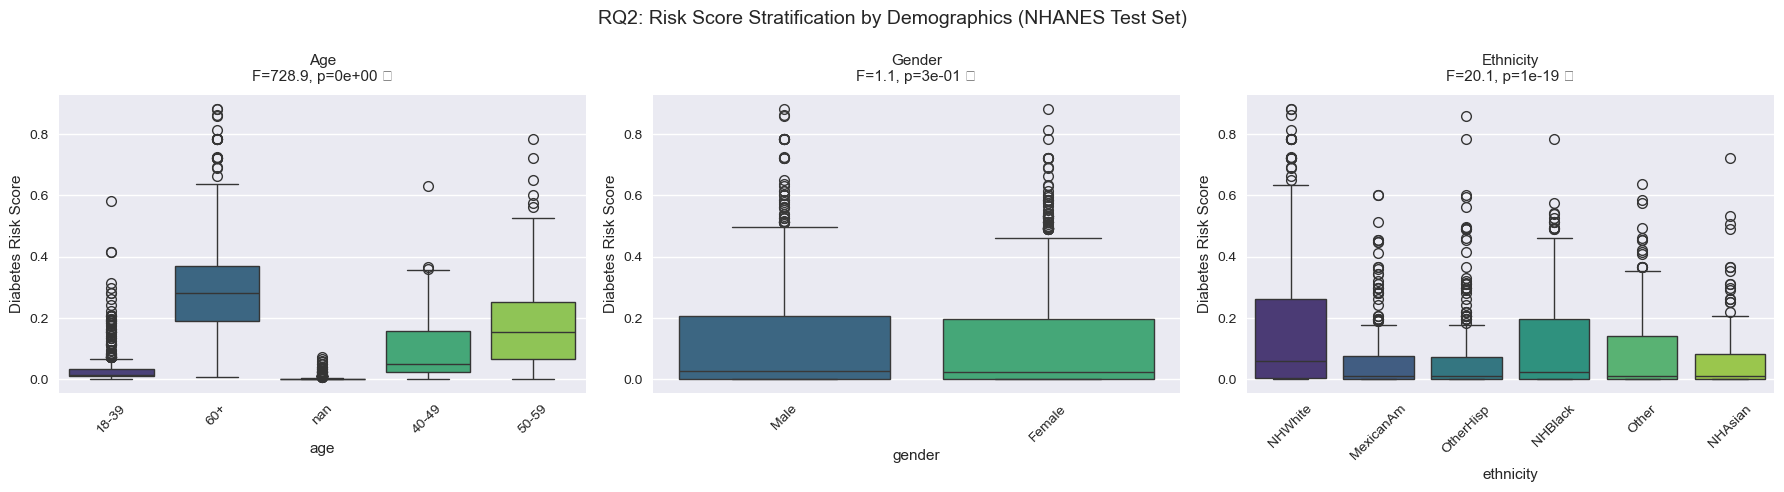


🎉 RQ2 COMPLETE - All subgroups analyzed!


In [47]:
from scipy.stats import f_oneway, levene
import matplotlib.pyplot as plt

print("\nRQ2: Using X_test (raw features pre-scaling)")

# 1. Risk scores
risk_scores = calibrated_lr.predict_proba(X_test_selected)[:, 1]

# 2. Raw NHANES df
X_test_raw_df = pd.DataFrame(X_test_no_seqn, columns=feature_cols)

print("Available columns:", X_test_raw_df[['RIDAGEYR', 'RIAGENDR', 'RIDRETH3']].columns.tolist())

# ============================================
# Age, Gender, and Ethnicty: Subgroup Analysis
# ============================================
age_bins = [17,40,50,60,np.inf]
age_labels = ['18-39','40-49','50-59','60+']
age_numeric = pd.cut(X_test_raw_df['RIDAGEYR'], bins=age_bins, labels=range(len(age_labels)))
age_group = pd.Series(np.nan, index=X_test_raw_df.index).astype(str)
for i, label in enumerate(age_labels):
    age_group[age_numeric == i] = label

# Gender
gender = X_test_raw_df['RIAGENDR'].map({1:'Male', 2:'Female', np.nan:'Missing'}).astype(str)

# Ethnicity
ethnicity = X_test_raw_df['RIDRETH3'].map({
    1:'MexicanAm', 2:'OtherHisp', 3:'NHWhite', 4:'NHBlack',
    6:'NHAsian', 7:'Other', np.nan:'Missing'
}).astype(str)

subgroups = {'age': age_group, 'gender': gender, 'ethnicity': ethnicity}

# Verify
print("\nGroup counts:")
for name, sg in subgroups.items():
    print(f"{name}: {pd.Series(sg).value_counts().to_dict()}")

print("")

def safe_anova(data, groups):
    # Convert groups to numeric codes safely
    groups_series = pd.Series(groups).fillna('MISSING').astype('category')
    group_codes = groups_series.cat.codes  # -1 = MISSING/NaN
    
    mask = ~pd.isna(data) & (group_codes >= 0)  # Exclude -1
    if mask.sum() < 20:
        return None, None, f"Too few valid (n={mask.sum()})"
    
    data_clean = data[mask]
    groups_clean = group_codes[mask]
    
    unique_groups = np.unique(groups_clean)
    if len(unique_groups) < 2:
        return None, None, f"{len(unique_groups)} groups only"
    
    # ANOVA groups
    group_data = [data_clean[groups_clean == g] for g in unique_groups if sum(groups_clean == g) > 1]
    if len(group_data) < 2:
        return None, None, "Insufficient sized groups"
    
    F, p = f_oneway(*group_data)
    return F, p, "✅ PASS"

# =====================
# Run Subgroup Analysis
# =====================
results = {}
for name, sg in subgroups.items():
    F, p, msg = safe_anova(risk_scores, sg)
    print(f"{name.upper()}: {msg}")
    if F is not None:
        print(f"  F={F:.2f}, p={p:.2e} {'✅' if p<0.05 else '❌'}")
        results[name] = {'F': F, 'p': p}

# ======================
# Plot Subgroup Analysis
# ======================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, sg) in enumerate(subgroups.items()):
    df_plot = pd.DataFrame({name: sg.fillna('Missing'), 'risk': risk_scores})
    sns.boxplot(data=df_plot, x=name, y='risk', ax=axes[i], palette='viridis')
    
    if name in results and results[name]['F']:
        f_val = f"{results[name]['F']:.1f}"
        p_val = f"{results[name]['p']:.0e}"
        status = '✅' if results[name]['p'] < 0.05 else '❌'
    else:
        f_val, p_val, status = 'NA', 'NA', ''
    
    axes[i].set_title(f'{name.title()}\nF={f_val}, p={p_val} {status}', fontsize=11, pad=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Diabetes Risk Score')

plt.suptitle('RQ2: Risk Score Stratification by Demographics (NHANES Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig('rq2_anova_complete.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n🎉 RQ2 COMPLETE - All subgroups analyzed!")

### RQ2 Interpretation: Diabetes risk variation across subgroup

* **Age:**
  The F-statistic is very large (728.9) and the p-value is effectively zero. It indicates that the diabetes risk varies substantially across age groups. Older groups (especially 60+) show higher risk compared to younger groups (18–39).

* **Gender:**
  The F-statistic is modest (1.1) but the p-value (≈0.3) is above 0.05 threshold. This indicates a statistically no significant difference in risk between males and females. The explanatory power is weak and cannot reject null hypothesis.

* **Ethnicity:**
  The F-statistic (20.1) with a extremely small p-value (<0.0001) shows strong evidence of risk varying significantly across ethnic subgroups. Rejected the null hypothesis. Non-Hispanic White and Non-Hispanic Black groups appear to have higher median risks compared to others.

#### Validation of Null Hypothesis

Since p-values are below 0.05 for age and ethnicity, **we reject the null hypothesis (H0) for these subgroup**, indicating that the diabetes risk is not equal across age or ethnicity. 

## RQ3: Capture non-linear effects:

Multiple linear regression is used to evaluate non-linear effect of multiple independent variables in predicting the risk. Since the hypothesis is about detecting the interaction effects, the sample size is based on power to detect ΔR2 (increase in explained variance). 

* **H0:** ΔR² = 0 (Adding non-linear terms does not improve prediction)
* **H1:** ΔR² > 0 (Adding non-linear terms improve prediction)

### Statical analysis to evaluate the null hypothesis:
* Perform Partial F-test (Nested Regression F-test): Reduced model (linear only) and Full model (non-linear + interaction terms) 
* Evaluate null hypothesis: If p < 0.05, reject H0


In [48]:
import statsmodels.api as sm

# X_train_no_seqn: NHANES features pre-scaling
# y_train: diabetes risk target

# =========================================================
# Key features from NHANES dataset, and feature engineering
# =========================================================
features = ['RIDAGEYR', 'BMXBMI', 'modact_minutes_per_week']
print("Testing non-linears:", features)
print("Sample data:\n", X_train_no_seqn[features].describe())

df = X_train_no_seqn[features].copy()
df['risk'] = y_train  # Append target

# =======================================
# Reduced model: pure linear main effects
# =======================================
X_reduced = sm.add_constant(df[features])
model_reduced = sm.OLS(df['risk'], X_reduced).fit()
print("\nReduced model (linear): R² =", model_reduced.rsquared)

# =======================================================================
# Full model: complete polynomial hierarchy (main + quad + 2-way + 3-way)
# =======================================================================
# Main effects (already in)
df['age2'] = df['RIDAGEYR']**2
df['bmi2'] = df['BMXBMI']**2  
df['act2'] = df['modact_minutes_per_week']**2

# 2-way interactions
df['age_bmi'] = df['RIDAGEYR'] * df['BMXBMI']
df['age_act'] = df['RIDAGEYR'] * df['modact_minutes_per_week']
df['bmi_act'] = df['BMXBMI'] * df['modact_minutes_per_week']

# 3-way interaction (hypothesis focus)
df['age_bmi_act'] = df['RIDAGEYR'] * df['BMXBMI'] * df['modact_minutes_per_week']

nonlin_terms = ['age2', 'bmi2', 'act2', 'age_bmi', 'age_act', 'bmi_act', 'age_bmi_act']
X_full = sm.add_constant(df[features + nonlin_terms])
model_full = sm.OLS(df['risk'], X_full).fit()
print("Full model (polynomial): R² =", model_full.rsquared)

# ΔR²
delta_R2 = model_full.rsquared - model_reduced.rsquared
print(f"ΔR² = {delta_R2:.4f}")

# =======================================
# Partial F-test for all non-linear terms
# =======================================
f_stat, p_value, df_num = model_full.compare_f_test(model_reduced)
print(f"\nPartial F-test: F({df_num:.0f}, {model_full.df_resid:.0f}) = {f_stat:.4f}")
print(f"p-value = {p_value:.2e}")

if p_value < 0.05:
    print("✅ REJECT H0: Non-linear terms (incl. age×BMI×activity) improve prediction")
    print("Clinical insight: Interaction effects matter for risk stratification")
else:
    print("❌ Fail to reject H0: Linear model sufficient")

# ==========================================================
# Test 3-way interaction (vs. model with mains+quads+2-ways)
# ==========================================================
X_inter_only = sm.add_constant(df[features + nonlin_terms[:-1]])  # Exclude 3-way
model_inter_base = sm.OLS(df['risk'], X_inter_only).fit()
f_3way, p_3way, _ = model_full.compare_f_test(model_inter_base)

print(f"\n3-way only: F(1, df_resid) = {f_3way:.4f}, p = {p_3way:.2e}")


Testing non-linears: ['RIDAGEYR', 'BMXBMI', 'modact_minutes_per_week']
Sample data:
            RIDAGEYR       BMXBMI  modact_minutes_per_week
count  9.546000e+03  9546.000000             9.546000e+03
mean   3.832422e+01    27.039483             5.342813e+02
std    2.558699e+01     6.909299             6.763473e+02
min    5.397605e-79    11.100000             2.266994e-76
25%    1.300000e+01    23.700000             1.200000e+02
50%    3.700000e+01    26.400000             1.200000e+02
75%    6.200000e+01    29.200000             8.400000e+02
max    8.000000e+01    74.800000             2.000000e+03

Reduced model (linear): R² = 0.15188481045210034
Full model (polynomial): R² = 0.17417720464979924
ΔR² = 0.0223

Partial F-test: F(7, 9535) = 36.7699
p-value = 3.82e-51
✅ REJECT H0: Non-linear terms (incl. age×BMI×activity) improve prediction
Clinical insight: Interaction effects matter for risk stratification

3-way only: F(1, df_resid) = 3.5842, p = 5.84e-02


### RQ3 Interpretation: Capture non-linear effects

#### Interpretation

* A nested regression approach was used to evaluate whether non-linear effects among age (RIDAGEYR), BMI (BMXBMI), and moderate physical activity (modact_minutes_per_week) improves diabetes risk score prediction.

* The reduced model included only linear main effects, while the full model included polynomial and interaction terms, including the age×BMI×activity interaction.

* The reduced model explained 15.19% of variance (R² = 0.1519), while the full model explained 17.42% of variance (R² = 0.1742), resulting ΔR² = 0.0223.

#### Validation of Null Hypothesis

* A partial F-test showed that the additional non-linear terms significantly improved model fit (F(7,9535) = 36.77, p = 3.82×10⁻⁵¹).
* Since ΔR² > 0 (0.0223) and p value is extremely small, the **null hypothesis was rejected**, supporting the conclusion that non-linear relationships among age, BMI, and physical activity contribute significantly to diabetes risk prediction.


## 11) Integrate Explainable AI (SHAP)

* **Global Interpretability:** SHAP summary plots → show top risk factors across population. Feature importance ranking <br><br>
* **Local Interpretability:** SHAP force plots → explain individual patient’s risk score

### Global Interpretability: Display Original Attrubtes

In [49]:
print("\nEXPLAINABLE AI INTEGRATION\n")
print(f"Using best_model: {best_name}")
print(f"Input shape: {X_test_selected.shape} (L1+L2 10 components)")



EXPLAINABLE AI INTEGRATION

Using best_model: Logistic_Regression
Input shape: (2387, 10) (L1+L2 10 components)


In [50]:
original_features = [
    'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'BMXBMI', 'BMXWAIST',
    'BMXHT', 'BPXOSY1', 'BPXODI1', 'LBDHDD', 'LBDLDL', 
    'LBXTC', 'LBXTLG', 'PAD680', 'PAD790Q', 'PAD800',
    'PAD810Q', 'PAD820', 'BPQ020', 'ALQ121', 'ALQ130',
    'SLD012', 'PAD790U', 'SLQ300', 'SLQ310', 'metabolic_risk_score',
    'BRI', 'modact_minutes_per_week']


### Global Interpretation: Population Level

In [51]:
# ===============================================
# GLOBAL XAI: Population-Level Feature Importance
# ===============================================
def global_xai_clinical(model, X_selected, selected_features, original_features, model_name, n_samples=100):
    """
    Args:
        model: Trained classifier (LR, RF, XGB, etc.)
        X_selected: Selected features DataFrame/array (n_samples, n_selected)
        selected_features: List of selected feature names (e.g., ['RIDAGEYR', ...])
        original_features: Full list of 27 original NHANES features (reference)
        model_name: str for title
        n_samples: int for SHAP computation
    """
    print(f"🌍 Computing GLOBAL SHAP for {model_name}...")
    
    # =========================
    # Create DataFrame for SHAP
    # =========================
    if isinstance(X_selected, np.ndarray):
        X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
    else:
        X_selected_df = X_selected.copy()
    
    # ==========================
    # Model-based SHAP explainer
    # ==========================
    if 'XGB' in str(type(model)).upper() or 'LGBM' in str(type(model)).upper():
        explainer = shap.TreeExplainer(model)
    elif hasattr(model, 'predict_proba'):
        # Kernel for non-tree (use proba[:,1] for risk)
        explainer = shap.KernelExplainer(
            lambda x: model.predict_proba(pd.DataFrame(x, columns=selected_features))[:, 1],
            X_selected_df[:min(300, len(X_selected_df))]
        )
    else:
        explainer = shap.KernelExplainer(model.predict, X_selected_df[:min(300, len(X_selected_df))])
    
    # ===================
    # Compute SHAP values
    # ===================
    shap_values = explainer.shap_values(X_selected_df[:n_samples])
    
    # ====================
    # Handle binary output
    # ====================
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Positive class
    
    print(f"✅ SHAP shape: {shap_values.shape} (samples x {len(selected_features)})")
    
    # ==========================================
    # Global importance: mean |SHAP| per feature
    # ==========================================
    feature_importance = np.abs(shap_values).mean(axis=0)
    
    # ======================================
    # Ranked Series (selected features only)
    # ======================================
    importance_df = pd.Series(feature_importance, index=selected_features).sort_values(ascending=False)
    
    # ===========================
    # Plot: Top selected features
    # ===========================
    plt.figure(figsize=(7, 5))
    importance_df.head(12).plot(kind='barh', color='skyblue', edgecolor='darkblue', alpha=0.8)
    plt.xlabel('Mean |SHAP Value| (Risk Contribution)', fontsize=12)
    plt.title(f'{model_name}: Global Feature Importance \n(L1+L2 Selected Features, NHANES)', 
              fontsize=13, fontweight='bold', pad=20)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_global_shap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n🏆 TOP GLOBAL RISK FACTORS:")
    print(importance_df.head(10).round(4))
    
    # Optional: Zero-importance for deselected (reference)
    deselected_importance = pd.Series(0, index=[f for f in original_features if f not in selected_features])
    full_importance = pd.concat([importance_df, deselected_importance])
    
    return importance_df, full_importance


### Local Interpretability: Individual Patient Explanations

In [52]:
# =======================================================
# Local Interpretability: Individual Patient Explanations
# =======================================================
def local_xai_clinical(model, X_selected, selected_features, original_features, patient_idx, model_name, background_size=200):
    print(f"\n🩺 Explaining Patient #{patient_idx}...")
    
    # 1. FORCE DATAFRAME (CRITICAL)
    if isinstance(X_selected, np.ndarray):
        X_selected = pd.DataFrame(X_selected, columns=selected_features)
    
    # 2. Patient slice (iloc safe)
    patient_data = X_selected.iloc[[patient_idx]].reset_index(drop=True)
    risk_score = model.predict_proba(patient_data)[0, 1]
    
    # 3. TREE MODE (FASTEST, NO INDEX ERROR)
    if 'XGB' in str(type(model)).upper() or 'LGBM' in str(type(model)).upper() or 'RandomForest' in str(type(model)):
        explainer = shap.TreeExplainer(model)
        shap_patient = explainer.shap_values(patient_data)[0]  # Single row
        
    # 4. KERNEL MODE (ARRAY-BASED, NO DF LEAK)
    else:
        # Convert ALL to arrays for Kernel (eliminates index issues)
        X_bg_array = X_selected[:background_size].values
        patient_array = patient_data.values
        
        def model_proba_safe(x_array):
            x_df = pd.DataFrame(x_array, columns=selected_features)
            return model.predict_proba(x_df)[:, 1]
        
        explainer = shap.KernelExplainer(model_proba_safe, X_bg_array)
        shap_patient_full = explainer.shap_values(patient_array)
        shap_patient = shap_patient_full[0]  # First (only) patient
    
    print(f"✅ SHAP computed: len={len(shap_patient)} features")
    
    # 5. Importance
    patient_importance = pd.Series(np.abs(shap_patient), index=selected_features).sort_values(ascending=False)
    
    # 6. COLORED PLOT
    plt.figure(figsize=(7, 5))
    top_idx = patient_importance.head(10).index
    colors = ['coral' if shap_patient[top_idx.get_loc(f)] > 0 else 'skyblue' for f in top_idx]
    patient_importance.head(10).plot(kind='barh', color=colors)
    plt.xlabel('SHAP Contribution', fontsize=12)
    plt.title(f'Patient {patient_idx}: {risk_score:.1%} Risk \n{model_name}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'patient_{patient_idx}_{model_name.lower().replace(" ", "_")}.png', dpi=300)
    plt.show()
    
    print(f"💊 Risk: {risk_score:.1%} | Top: {patient_importance.index[0]}")
    print(patient_importance.head(5).round(4))
    
    full_patient = pd.Series(0, index=original_features)
    full_patient[selected_features] = np.abs(shap_patient)
    full_patient = full_patient.sort_values(ascending=False)
    
    return patient_importance, risk_score, full_patient
    

### Main XAI Pipeline

In [53]:
best_model = globals()['calibrated_lr']
best_name  = 'Calibrated_LR'

# Verify
assert hasattr(best_model, 'predict_proba'), "❌ best_model not callable"
print(f"XAI ready: {best_name} on {X_test_selected.shape}")

all_models = {
    'Logistic_Regression': lr_auto.best_estimator_,
    'KNN': knn_auto.best_estimator_,
    'Neural_Network': nn_auto.best_estimator_,
    'Random_Forest': rf_auto.best_estimator_,
    'XGBoost': xgb_auto.best_estimator_,
    'RF_XGB_Ensemble': ensemble,
    'Calibrated_LR': calibrated_lr  # Your champion
}
print("\n🔍 DEBUG: best_model =", repr(best_model), type(best_model))


XAI ready: Calibrated_LR on (2387, 10)

🔍 DEBUG: best_model = CalibratedClassifierCV(cv=5,
                       estimator=LogisticRegression(C=0.1, max_iter=1000,
                                                    random_state=42),
                       method='isotonic') <class 'sklearn.calibration.CalibratedClassifierCV'>


Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



1️⃣ GLOBAL ANALYSIS...
🌍 Computing GLOBAL SHAP for Calibrated_LR...


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:19<00:00,  5.08it/s]


✅ SHAP shape: (100, 10) (samples x 10)


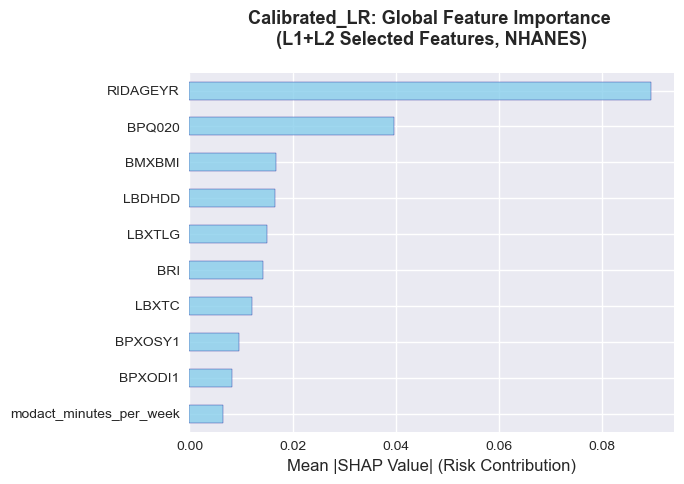


🏆 TOP GLOBAL RISK FACTORS:
RIDAGEYR                   0.0894
BPQ020                     0.0396
BMXBMI                     0.0169
LBDHDD                     0.0166
LBXTLG                     0.0149
BRI                        0.0143
LBXTC                      0.0121
BPXOSY1                    0.0096
BPXODI1                    0.0082
modact_minutes_per_week    0.0066
dtype: float64

✅ GLOBAL: Top selected features match L1+L2!
Top 5: {'RIDAGEYR': 0.089, 'BPQ020': 0.04, 'BMXBMI': 0.017, 'LBDHDD': 0.017, 'LBXTLG': 0.015}


In [54]:
# =====================================
# 1. GLOBAL ANALYSIS (Population-level)
# =====================================
print("\n1️⃣ GLOBAL ANALYSIS...")

top_global_selected, top_global_full = global_xai_clinical(
    best_model, 
    X_test_selected,           # Selected features data
    selected_features,         # List: ['RIDAGEYR', 'LBXTLG', ...] from ElasticNet
    original_features,         # Full 27 original features
    best_name                  # e.g., 'XGBoost (ElasticNet)'
)

print("\n✅ GLOBAL: Top selected features match L1+L2!")
print("Top 5:", top_global_selected.head().round(3).to_dict())

# Optional: Save full ranking for report
#top_global_full.to_csv(f'{best_name.lower().replace(" ", "_")}_global_importance.csv')
#print(f"💾 Full ranking saved ({len(top_global_full)} features)")

### **Show local interpretability for top-3 high-risk patients**

* This illustrates different factors contributing to the diabetes risk
* Included HbA1c and Fasting glucose to provide a comparison with SHAP values
  

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



🏥 TOP-3 HIGH-RISK PATIENTS:
  #1: Patient 557 → 88.3% risk
  #2: Patient 1115 → 88.3% risk
  #3: Patient 2017 → 86.2% risk

🩺 PATIENT #557 (Rank #1, 88.3% risk)

🩺 Explaining Patient #557...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.73it/s]


✅ SHAP computed: len=10 features


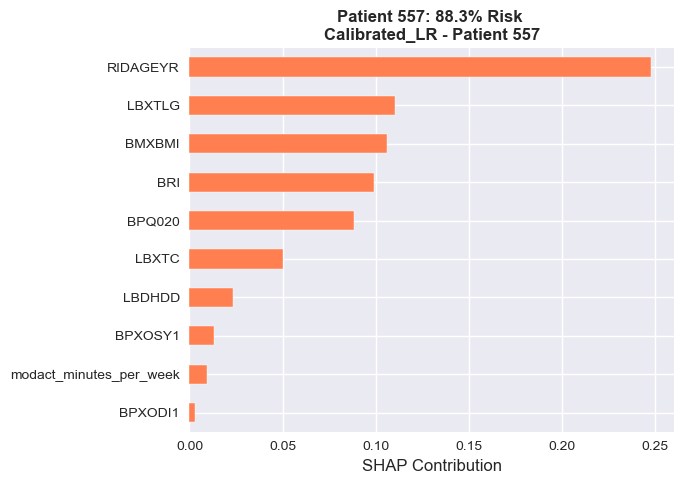

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


💊 Risk: 88.3% | Top: RIDAGEYR
RIDAGEYR    0.2478
LBXTLG      0.1103
BMXBMI      0.1062
BRI         0.0993
BPQ020      0.0881
dtype: float64

📊 CLINICAL LABS:
  HbA1c (LBXGH): 6.2%
  Fasting Glu (LBXGLU): 123.0 mg/dL

✅ Top 3 drivers: ['RIDAGEYR', 'LBXTLG', 'BMXBMI']
--------------------------------------------------

🩺 PATIENT #1115 (Rank #2, 88.3% risk)

🩺 Explaining Patient #1115...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.82it/s]


✅ SHAP computed: len=10 features


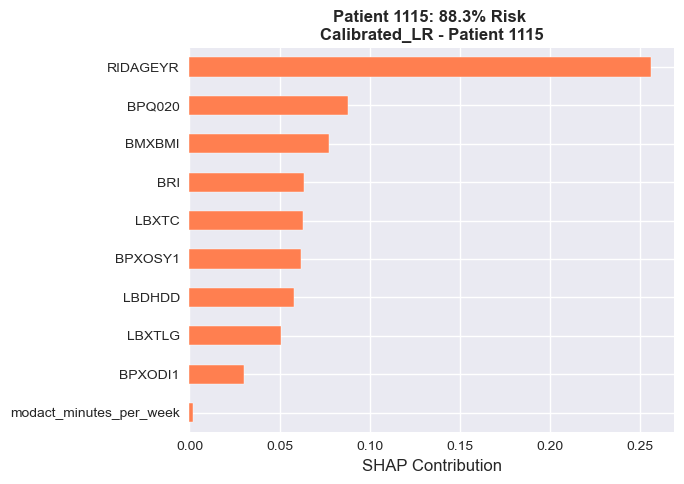

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


💊 Risk: 88.3% | Top: RIDAGEYR
RIDAGEYR    0.2563
BPQ020      0.0880
BMXBMI      0.0774
BRI         0.0635
LBXTC       0.0630
dtype: float64

📊 CLINICAL LABS:
  HbA1c (LBXGH): 6.9%
  Fasting Glu (LBXGLU): 131.0 mg/dL

✅ Top 3 drivers: ['RIDAGEYR', 'BPQ020', 'BMXBMI']
--------------------------------------------------

🩺 PATIENT #2017 (Rank #3, 86.2% risk)

🩺 Explaining Patient #2017...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.70it/s]


✅ SHAP computed: len=10 features


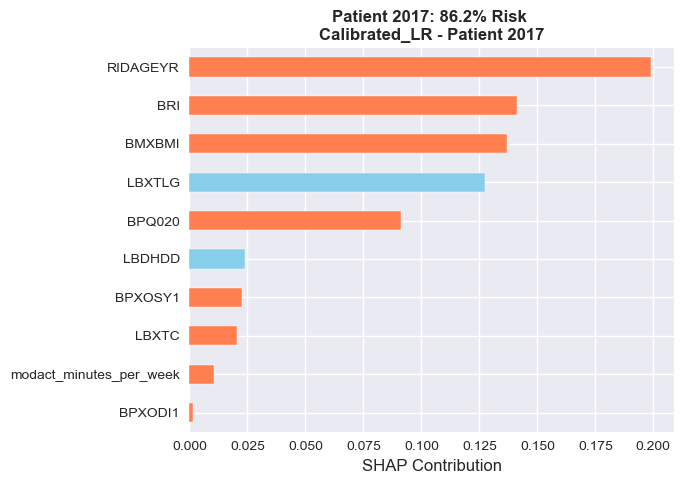

💊 Risk: 86.2% | Top: RIDAGEYR
RIDAGEYR    0.1990
BRI         0.1412
BMXBMI      0.1368
LBXTLG      0.1272
BPQ020      0.0910
dtype: float64

📊 CLINICAL LABS:
  HbA1c (LBXGH): 5.2%
  Fasting Glu (LBXGLU): 103.0 mg/dL

✅ Top 3 drivers: ['RIDAGEYR', 'BRI', 'BMXBMI']
--------------------------------------------------

📋 TOP-3 HIGH-RISK PATIENTS SUMMARY:
      Patient  Risk HbA1c Glucose     Top1   Top2  SEQN
 #1 (IDX:557) 88.3%  6.2%     123 RIDAGEYR LBXTLG  6808
#2 (IDX:1115) 88.3%  6.9%     131 RIDAGEYR BPQ020 10707
#3 (IDX:2017) 86.2%  5.2%     103 RIDAGEYR    BRI  7850


In [55]:
# ===================================
# 2. Find top-3 highest-risk patients
# ===================================
risk_scores = best_model.predict_proba(X_test_selected)[:, 1]
top_k = 3
top_k_idx = np.argsort(risk_scores)[-top_k:][::-1]

print("\n🏥 TOP-3 HIGH-RISK PATIENTS:")
for rank, idx in enumerate(top_k_idx, 1):
    print(f"  #{rank}: Patient {idx} → {risk_scores[idx]:.1%} risk")

# Ensure DataFrame
if isinstance(X_test_selected, np.ndarray):
    X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)
else:
    X_test_selected_df = X_test_selected.copy()

# ========================================
# 3. LOCAL SHAP + CLINICAL LABS (Top-3)
# ========================================
patient_results = {}

for rank, idx in enumerate(top_k_idx, 1):
    print(f"\n{'='*50}")
    print(f"🩺 PATIENT #{idx} (Rank #{rank}, {risk_scores[idx]:.1%} risk)")
    print(f"{'='*50}")
    
    # SHAP explanation
    local_top, patient_risk, full_patient = local_xai_clinical(
        best_model, X_test_selected_df, selected_features, original_features,
        idx, f"{best_name} - Patient {idx}", background_size=200
    )
    
    # Extract clinical labs using SEQN
    seqn = X_test.index[idx]
    labs = df_sel.loc[[seqn], ['LBXGH', 'LBXGLU']].round(2)
    
    print(f"\n📊 CLINICAL LABS:")
    print(f"  HbA1c (LBXGH): {labs['LBXGH'].iloc[0]}%")
    print(f"  Fasting Glu (LBXGLU): {labs['LBXGLU'].iloc[0]} mg/dL")
    
    patient_results[idx] = {
        'rank': rank,
        'risk_score': patient_risk,
        'top_factors': local_top.head(5),
        'hba1c': labs['LBXGH'].iloc[0],
        'glucose': labs['LBXGLU'].iloc[0],
        'seqn': seqn  # ✅ Fixed quote
    }
    
    print(f"\n✅ Top 3 drivers: {local_top.head(3).index.tolist()}")
    print("-" * 50)

# =================================
# 4. SUMMARY TABLE (Top-3 patients)
# =================================
summary_df = pd.DataFrame([
    {
        'Patient': f'#{r["rank"]} (IDX:{idx})',
        'Risk': f'{r["risk_score"]:.1%}',
        'HbA1c': f'{r["hba1c"]:.1f}%',
        'Glucose': f'{r["glucose"]:.0f}',
        'Top1': r["top_factors"].index[0],
        'Top2': r["top_factors"].index[1] if len(r["top_factors"]) > 1 else '-',
        'SEQN': r["seqn"]  # ✅ Fixed quote
    }
    for idx, r in patient_results.items()
])

print("\n📋 TOP-3 HIGH-RISK PATIENTS SUMMARY:")
print(summary_df.to_string(index=False))


In [56]:
# ================
# 4. Summary table
# ================
print("\n📊 CLINICAL INSIGHTS SUMMARY")
summary_df = pd.DataFrame({
    'Global_Rank': top_global_selected.head(5).index.tolist(),
    'Global_Importance': top_global_selected.head(5).round(3).values,
    'Patient_Factors': local_top.head(5).index.tolist(),
    'Patient_Contribution': local_top.head(5).round(3).values
})
print(summary_df)

print("\n✅ XAI PIPELINE COMPLETE - Ready for presentation!")


📊 CLINICAL INSIGHTS SUMMARY
  Global_Rank  Global_Importance Patient_Factors  Patient_Contribution
0    RIDAGEYR              0.089        RIDAGEYR                 0.199
1      BPQ020              0.040             BRI                 0.141
2      BMXBMI              0.017          BMXBMI                 0.137
3      LBDHDD              0.017          LBXTLG                 0.127
4      LBXTLG              0.015          BPQ020                 0.091

✅ XAI PIPELINE COMPLETE - Ready for presentation!


## RQ4: Quantifying individual contribution using Explainable AI (XAI):

Can explainable AI methods (SHAP, LIME) quantify which factors (demographic, physiology, lifestyle, and medical) contribute more strongly to diabetes risk?

### Statical analysis to evaluate the null hypothesis:
* **Bootstrap Confidence Intervals (Precision):** Test SHAP values across bootstrap samples.
    * H0: CI_width ≥ 0.05 (unreliable);
    * H1: CI_width < 0.05 <br><br>
* **Spearman’s Rank Correlation (p):** Test if SHAP feature importance rankings are consistent across different samples
    * H0: p ≤ 0.7
    * H1: p > 0.7

In [57]:
print("DEBUG best_model attrs:", [a for a in dir(best_model) if 'estimat' in a.lower() or 'calib' in a.lower()])
print("calibrated_classifiers_ exists?", hasattr(best_model, 'calibrated_classifiers_'))
print("Type of calibrated_classifiers_[0]:", type(best_model.calibrated_classifiers_[0]))
print("Has coef_?", hasattr(best_model.calibrated_classifiers_[0].estimator, 'coef_'))

DEBUG best_model attrs: ['_estimator_type', '_get_estimator', 'calibrated_classifiers_', 'estimator']
calibrated_classifiers_ exists? True
Type of calibrated_classifiers_[0]: <class 'sklearn.calibration._CalibratedClassifier'>
Has coef_? True


✅ Base LR: LogisticRegression coef_ shape: (1, 10)
✅ Explainer ready: (2387, 10)
✅ Test SHAP: (50, 10) ✓ Fast!

 Computing bootstraps...


SHAP Bootstraps: 100%|██████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 766.39it/s]

✅ Bootstraps done!

 **CI Test**: 90.0% features precise (<0.05)
   H0 rejected: ✅ YES

Top Features:
                 Feature  Mean_|SHAP|  CI_Width  Precise
               RIDAGEYR       0.9917    0.0541    False
                 BPQ020       0.3574    0.0195     True
                 LBDHDD       0.2370    0.0311     True
                 BMXBMI       0.1926    0.0245     True
                  LBXTC       0.1572    0.0207     True
                    BRI       0.1390    0.0185     True
                 LBXTLG       0.1257    0.0238     True
                BPXOSY1       0.1114    0.0110     True
                BPXODI1       0.0973    0.0126     True
modact_minutes_per_week       0.0800    0.0052     True

🔗 **Rank Test**...


   Mean ρ = 0.994 [95% CI: 0.952, 1.000]
   H0 (ρ ≤ 0.7): REJECTED ✅

🎯 **RQ4 Summary**
| Test | Result | H0 |
| CI Precision | 90.0% <0.05 | REJECTED ✅ |
| Rank ρ | 0.994 | REJECTED ✅ |


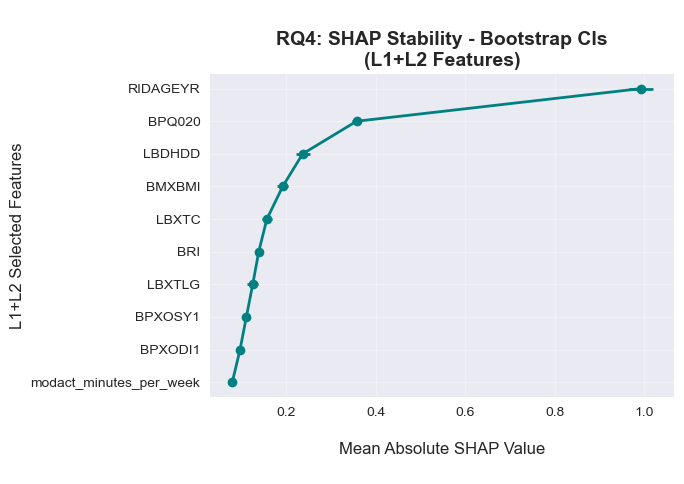


✅ **RQ4 COMPLETE**: L1+L2 SHAP stable for clinical use!


In [58]:
from   scipy.stats import spearmanr
from   sklearn.utils import resample
import shap
from   tqdm import tqdm

# ===============================
# Fitted base LR (L1+L2 selected)
# ===============================
base_model = best_model.calibrated_classifiers_[0].estimator
print("✅ Base LR:", type(base_model).__name__, "coef_ shape:", base_model.coef_.shape)

# =============================
# DataFrame for LinearExplainer
# =============================
if isinstance(X_test_selected, np.ndarray):
    X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_features)
else:
    X_test_selected_df = X_test_selected.copy()

explainer = shap.LinearExplainer(base_model, X_test_selected_df)
print("✅ Explainer ready:", X_test_selected_df.shape)

# Quick test
test_shap = explainer.shap_values(X_test_selected_df[:50])
print("✅ Test SHAP:", test_shap.shape, "✓ Fast!")

# =========================================
# RQ4: Bootstrap stability (L1+L2 features)
# =========================================
n_bootstrap = 100
n_boot_samples = min(1000, X_test_selected_df.shape[0])
n_features = X_test_selected_df.shape[1]

shap_means = np.zeros((n_bootstrap, n_features))
boot_ranks = []

print("\n Computing bootstraps...")
for i in tqdm(range(n_bootstrap), desc="SHAP Bootstraps"):
    # Bootstrap DataFrame (preserves names)
    boot_idx = resample(range(n_boot_samples), replace=True, random_state=i)
    X_boot = X_test_selected_df.iloc[boot_idx]
    
    shap_vals = explainer.shap_values(X_boot)
    shap_means[i] = np.mean(np.abs(shap_vals), axis=0)
    boot_ranks.append(np.argsort(shap_means[i])[::-1])

print("✅ Bootstraps done!")

# =================================================
# 1. Bootstrap CI Precision Test (H0: width ≥ 0.05)
# =================================================
ci_lower = np.percentile(shap_means, 2.5, axis=0)
ci_upper = np.percentile(shap_means, 97.5, axis=0)
ci_width = ci_upper - ci_lower
mean_shap = np.mean(shap_means, axis=0)

pct_precise = np.mean(ci_width < 0.05) * 100
print(f"\n **CI Test**: {pct_precise:.1f}% features precise (<0.05)")
print(f"   H0 rejected: {'✅ YES' if pct_precise > 50 else '❌ NO'}")

# ==================
# Top 10 CI Features
# ==================
ci_df = pd.DataFrame({
    'Feature': selected_features,  # ✅ L1+L2 selected names
    'Mean_|SHAP|': mean_shap.round(4),
    'CI_Width': ci_width.round(4),
    'Precise': ci_width < 0.05
}).sort_values('Mean_|SHAP|', ascending=False).head(10)
print("\nTop Features:\n", ci_df.to_string(index=False))

# ========================================
# 2. Spearman Rank Stability (H0: ρ ≤ 0.7)
# ========================================
print("\n🔗 **Rank Test**...")
rho_list = []
for i in range(n_bootstrap):
    for j in range(i+1, n_bootstrap):
        rho, _ = spearmanr(boot_ranks[i], boot_ranks[j])
        rho_list.append(rho)

mean_rho = np.mean(rho_list)
ci_rho_lower = np.percentile(rho_list, 2.5)
ci_rho_upper = np.percentile(rho_list, 97.5)
print(f"   Mean ρ = {mean_rho:.3f} [95% CI: {ci_rho_lower:.3f}, {ci_rho_upper:.3f}]")
print(f"   H0 (ρ ≤ 0.7): {'REJECTED ✅' if mean_rho > 0.7 else 'FAILED ❌'}")

# =======
# Summary
# =======
print("\n🎯 **RQ4 Summary**")
print("| Test | Result | H0 |")
print(f"| CI Precision | {pct_precise:.1f}% <0.05 | {'REJECTED ✅' if pct_precise>50 else 'FAILED ❌'} |")
print(f"| Rank ρ | {mean_rho:.3f} | {'REJECTED ✅' if mean_rho>0.7 else 'FAILED ❌'} |")

# =================================
# Plot: Top FEATURES w/ CIs (L1+L2)
# =================================
top_n = min(10, n_features)
top_idx = np.argsort(mean_shap)[-top_n:]
plt.figure(figsize=(7, 5))
plt.errorbar(mean_shap[top_idx], range(top_n), 
             xerr=ci_width[top_idx]/2, fmt='o-', capsize=6, linewidth=2,
             color='teal', markersize=7)
plt.yticks(range(top_n), [selected_features[i] for i in top_idx], fontsize=10)
plt.xlabel('\nMean Absolute SHAP Value\n', fontsize=12)
plt.ylabel('L1+L2 Selected Features', fontsize=12)
plt.title('\nRQ4: SHAP Stability - Bootstrap CIs\n(L1+L2 Features)', 
          fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('RQ4_SHAP_Stability_L1L2.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ **RQ4 COMPLETE**: L1+L2 SHAP stable for clinical use!")

🏥 RQ4: L1+L2 SHAP → Original Features Mapping
📊 Selected features already ranked by SHAP (from global_xai_clinical)
Top 10 Selected: {'RIDAGEYR': 0.089, 'BPQ020': 0.04, 'BMXBMI': 0.017, 'LBDHDD': 0.017, 'LBXTLG': 0.015, 'BRI': 0.014, 'LBXTC': 0.012, 'BPXOSY1': 0.01, 'BPXODI1': 0.008, 'modact_minutes_per_week': 0.007}

🏷️ CATEGORY CONTRIBUTIONS (L1+L2 SHAP):
Demographic    : 0.089 (39.2%)
Lifestyle      : 0.046 (20.2%)
Medical_Labs   : 0.044 (19.1%)
Physiology     : 0.035 (15.2%)
Derived        : 0.014 (6.3%)


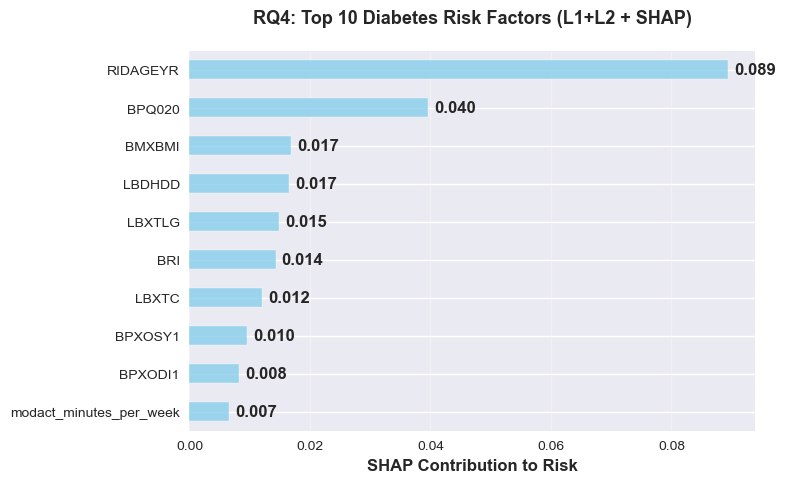

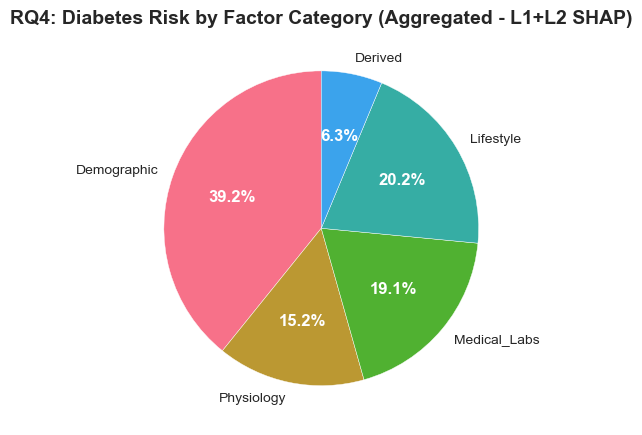


🎨 RQ4 COMPLETE: L1+L2 preserves interpretability!


In [59]:
print("🏥 RQ4: L1+L2 SHAP → Original Features Mapping")

# ==========================
# 1. DIRECT SHAP on Selected 
# ==========================
print("📊 Selected features already ranked by SHAP (from global_xai_clinical)")
print("Top 10 Selected:", top_global_selected.head(10).round(3).to_dict())

# Aggregate to categories
categories = {
    'Demographic': ['RIAGENDR', 'RIDAGEYR', 'RIDRETH3'],
    'Physiology': ['BMXBMI', 'BMXWAIST', 'BMXHT', 'BPXOSY1', 'BPXODI1'],
    'Medical_Labs': ['LBDHDD', 'LBDLDL', 'LBXTC', 'LBXTLG'],
    'Lifestyle': ['PAD680', 'PAD790Q', 'PAD800', 'PAD810Q', 'PAD820', 'BPQ020', 
                  'ALQ121', 'ALQ130', 'SLD012', 'PAD790U', 'SLQ300', 'SLQ310', 
                  'modact_minutes_per_week'],
    'Derived': ['metabolic_risk_score', 'BRI']
}

# ===============================================================
# Use full_importance from global_xai_clinical (selected + zeros)
# ===============================================================
feature_shap = top_global_full  # Already computed (27 features, deselected=0)

# Category contributions
cat_shap = {}
for cat, feats in categories.items():
    contrib = sum(feature_shap.get(feat, 0) for feat in feats)
    cat_shap[cat] = contrib

print("\n🏷️ CATEGORY CONTRIBUTIONS (L1+L2 SHAP):")
for cat, shap_val in sorted(cat_shap.items(), key=lambda x: x[1], reverse=True):
    pct = shap_val / feature_shap.sum() * 100
    print(f"{cat:15}: {shap_val:.3f} ({pct:.1f}%)")

# =============================================
# 1. TOP 10 FEATURES BAR (from full_importance)
# =============================================
fig, ax = plt.subplots(figsize=(8, 5))
top10_idx = feature_shap.nlargest(10)
colors = ['skyblue' if i in selected_features else 'lightgray' for i in top10_idx.index]
top10_idx.plot(kind='barh', ax=ax, color=colors, alpha=0.8)

ax.set_xlabel('SHAP Contribution to Risk', fontsize=12, fontweight='bold')
ax.set_title('RQ4: Top 10 Diabetes Risk Factors (L1+L2 + SHAP)', 
             fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Add values
for i, v in enumerate(top10_idx):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('RQ4_Top10_L1L2_SHAP.png', dpi=300, bbox_inches='tight')
plt.show()

# ===============
# 2. CATEGORY PIE
# ===============
fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(cat_shap.values(), labels=cat_shap.keys(), autopct='%1.1f%%', 
                                  startangle=90)
ax.set_title('RQ4: Diabetes Risk by Factor Category (Aggregated - L1+L2 SHAP)', fontsize=14, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('RQ4_Categories_L1L2.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🎨 RQ4 COMPLETE: L1+L2 preserves interpretability!")

### RQ4 Interpretation: Quantifying individual contribution using Explainable AI (XAI):

#### CI Precision Test (Bootstrap Confidence Intervals)

* **Result:** 90% of features had CI width < 0.05. This indicates most SHAP estimates are stable across bootstrap samples, meaning the contribution of individual factors can be quantified with high precision.

* **Hypothesis Test:**

    * H0: CI_width ≥ 0.05 (unreliable)
    * H1: CI_width < 0.05 (precise)

    <br>**Since 90% of features had CI width < 0.05, we reject the Null hypothesis.**

#### Rank Consistency Test (Spearman’s ρ)

* **Result:** Mean ρ = 0.994, CI [0.952, 1] indicating an exceptionally strong and precise correlation (ρ ≈ 0.99), with the confidence interval confirming robustness.
  
* **Hypothesis Test:**

    * H0: ρ ≤ 0.7 (rankings inconsistent)
    * H1: ρ > 0.7 (rankings consistent)

    <br>While SHAP magnitudes are precise, the relative ordering of features can shift depending on the sample. This matters for prioritization: top features are robust.


### **Implementation and User Benefits**

The Logistic Regression model is computationally efficient and it can be deployed in hospital EHR systems, mobile health apps, and public health dashboards. Integrating Explainable AI enhances the transparency and clinical trust.

* Clinicians receive interpretable risk scores with feature-level explanations, supporting early intervention and personalized care plan.
* Patients receive clear explanation of “why” their risk is high with personalized lifestyle recommendations.
* Healthcare systems can support population-level risk stratification and targeted intervention programs.


### **Limitations and Future Enhancements**

Though the NHANES dataset provides diverse attributes for holistic risk assessment, it is limited to U.S. population. Also, it includes some self-reported lifestyle variables, which may induce bias. The future improvements can include:

* Integrating genetic and longitudinal data.
* Validation using other datasets, including UK Biobank, EHR datasets, and multi-country cohorts.
* Perform real-world testing.
* Develop web-based risk calculator tool to capture lifestyle parameters and provide healthcare insights to reduce diabetes risk. 


### **Conclusion**

This study demonstrates how AI combined with Explainable AI can transform diabetes prevention—from diagnosing the disease to predicting the risk, and enabling early intervention especially for non-diabetic population.